# 1. 개발 환경 세팅하기

In [1]:
!pip install koreanize_matplotlib
!pip install statsmodels

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import scipy.stats as stats
import statsmodels.api as sm

%config InlineBackend.figure_format = 'retina'

## 파일 불러오기

In [3]:
mmr_df = "C:/Users/PC/Desktop/김필준/data/2026 난민_0415.csv"


In [4]:
try:
    mmr_df = pd.read_csv(mmr_df, encoding='utf-8', on_bad_lines='skip')
    print("UTF-8 인코딩으로 데이터 로드에 성공했습니다.")
except UnicodeDecodeError:
    mmr_df = pd.read_csv(mmr_df, encoding='cp949', on_bad_lines='skip')
    print("CP949 인코딩으로 데이터 로드에 성공했습니다.")

UTF-8 인코딩으로 데이터 로드에 성공했습니다.


## 🧹 데이터 결측값 및 이상치 사전 검증

LoL 게임은 한 경기당 반드시 10명의 플레이어로 구성된다.  
하지만 실제 데이터 수집 과정에서는 회원 탈퇴, 로그 누락, API 수집 오류 등의 이유로  
일부 경기 데이터가 불완전하게 기록될 가능성이 존재한다.

이러한 문제를 방치할 경우 다음과 같은 문제가 발생할 수 있다:

- 특정 경기의 인원이 10명이 아닌 경우 → 팀 단위 지표 왜곡
- 일부 변수 결측 → Game Impact 계산 오류
- 상대 비교 및 인분 지표 산출 불가능
- 모델 학습 시 편향 발생

따라서 본 프로젝트에서는 분석에 영향을 주지 않는 일부 컬럼을 제외한 후,  
핵심 지표에 결측값이 존재하는 데이터를 사전에 식별하였다.

이를 통해:
- 분석에 사용 가능한 데이터의 신뢰도를 확보하고
- 지표 계산 과정에서 발생할 수 있는 오류를 방지하며
- 전체 MMR 산정 로직의 안정성을 보장하였다

In [5]:
mmr_df['replay_code'].value_counts()

print(mmr_df.duplicated().sum())

mmr_df_cleaned_default = mmr_df.drop_duplicates()

mmr_df_cleaned_default['replay_code'].value_counts()

0


replay_code
RPY-260108-1t_0108_2009-2        10
RPY-260316-2t_0316_0048-1698     10
RPY-260316-1t_0316_0000-1693     10
RPY-260316-2t_0315_2356-1692     10
RPY-260315-1t_0315_2315_-1691    10
                                 ..
RPY-260217-1t_0217_2010-963      10
RPY-260217-2t_0217_2010-962      10
RPY-260217-1t_0217_1935-961      10
RPY-260217-2t_0217_1928-960      10
RPY-260415-1t_0415_0158-2426     10
Name: count, Length: 1850, dtype: int64

In [6]:
# 제외할 컬럼 정의
exclude_cols = [
    'jungle_cs_own', 'jungle_cs_enemy', 'dragon_kills', 'baron_kills',
    'herald_kills', 'horde_kills', 'damage_to_epic_monsters',
    'objectives_stolen', 'barracks_killed'
]

# 제외 컬럼 제거한 데이터프레임 생성
check_df = mmr_df_cleaned_default.drop(columns=exclude_cols)

# NA가 하나라도 있는 행 추출
rows_with_na = mmr_df_cleaned_default[check_df.isnull().any(axis=1)]

# 출력
print("--- Rows containing NA (missing values, excluding specific columns) ---")
print(rows_with_na)

# 개수 확인
print(f"\nNA (missing values) were found in a total of {len(rows_with_na)} rows.")

--- Rows containing NA (missing values, excluding specific columns) ---
          id            guild_id                   replay_code  \
0      36881  754305741304627212     RPY-260108-1t_0108_2009-2   
1      36882  754305741304627212     RPY-260108-1t_0108_2009-2   
2      36883  754305741304627212     RPY-260108-1t_0108_2009-2   
3      36884  754305741304627212     RPY-260108-1t_0108_2009-2   
5      36886  754305741304627212     RPY-260108-1t_0108_2009-2   
...      ...                 ...                           ...   
18493  55374  754305741304627212  RPY-260415-1t_0415_0158-2426   
18495  55376  754305741304627212  RPY-260415-1t_0415_0158-2426   
18496  55377  754305741304627212  RPY-260415-1t_0415_0158-2426   
18497  55378  754305741304627212  RPY-260415-1t_0415_0158-2426   
18498  55379  754305741304627212  RPY-260415-1t_0415_0158-2426   

                                      puuid champion_id position  team    win  \
0      f9ddea1d-7bd9-54a6-98aa-0c122b2bbbab      CHN_2

In [7]:
# 중복 제거 후 .copy()
mmr_df_cleaned_default = mmr_df.drop_duplicates().copy()

# win -> game_result 변환
mmr_df_cleaned_default['game_result'] = (
    mmr_df_cleaned_default['win']
    .astype(str)
    .str.upper()
    .map({'TRUE': 1, 'FALSE': 0})
)

mmr_df_cleaned_default.drop(columns=['win'], inplace=True)


# 서포트 전용 지표 NULL -> 0 처리
mmr_df_cleaned_default['heal_on_teammates'] = mmr_df_cleaned_default['heal_on_teammates'].fillna(0)
mmr_df_cleaned_default['shield_on_teammates'] = mmr_df_cleaned_default['shield_on_teammates'].fillna(0)

# game_duration 분 단위 변환
mmr_df_cleaned_default['game_duration'] = (
    mmr_df_cleaned_default['game_duration'] / 60
).round(2)

# 0으로 나누기 방지용 duration
duration_for_calc = mmr_df_cleaned_default['game_duration'].replace(0, np.nan)

# 승패 분리
mmr_df_win_df = mmr_df_cleaned_default[
    mmr_df_cleaned_default['game_result'] == 1
].reset_index(drop=True)

mmr_df_lose_df = mmr_df_cleaned_default[
    mmr_df_cleaned_default['game_result'] == 0
].reset_index(drop=True)

print("승리한 게임 데이터:")
print(mmr_df_win_df.head())

print("\n패배한 게임 데이터:")
print(mmr_df_lose_df.head())

print("\n추가 지표 포함 데이터프레임 미리보기:")
print(
    mmr_df_cleaned_default[
        [
            'deaths', 'damage_taken', 'damage_taken_per_death',
            'damage_to_champions', 'damage_dealt_per_death',
            'wards_placed', 'wards_killed', 'cc_time',
            'heal_on_teammates', 'shield_on_teammates', 'lane_gold_diff'
        ]
    ].head()
)

승리한 게임 데이터:
      id            guild_id                replay_code  \
0  36886  754305741304627212  RPY-260108-1t_0108_2009-2   
1  36887  754305741304627212  RPY-260108-1t_0108_2009-2   
2  36888  754305741304627212  RPY-260108-1t_0108_2009-2   
3  36889  754305741304627212  RPY-260108-1t_0108_2009-2   
4  36890  754305741304627212  RPY-260108-1t_0108_2009-2   

                                  puuid champion_id position  team  \
0  f5a173bf-10b4-52bc-9a5d-002808b72f5e     CHN_131      TOP   200   
1  d96e2c4b-96c3-5089-b786-05b994f847af      CHN_78   JUNGLE   200   
2  60c6f4f8-34f5-5ffd-b2a4-a2e33730d642     CHN_161   MIDDLE   200   
3  e7ba9d3d-8d5f-5d45-8b5e-943fc25c6b76      CHN_10   BOTTOM   200   
4  241fe26c-57e7-5481-9f4e-ad52521eb3bc     CHN_118  UTILITY   200   

   game_duration  kills  deaths  ...  barracks_killed  heal_on_teammates  \
0          23.75      5       3  ...              0.0                0.0   
1          23.75      9       0  ...              NaN       

# 📊 포지션별 승패 기여 지표 분석 및 가중치 설정

포지션마다 승리에 기여하는 핵심 능력치는 다르기 때문에,  
동일한 기준으로 모든 포지션을 평가하면 실제 역할 수행 능력이 왜곡될 수 있다.  
이를 보완하기 위해 포지션별 데이터를 분리하고, RandomForest 기반 Feature Importance를 통해  
각 지표의 승패 기여도를 산출하였다.  
이 결과는 이후 포지션별 Game Impact Score 계산 시 가중치로 활용되었다.

## 각 포지션 별 가중치 정하기

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18020\135544764.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18020\135544764.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18020\135544764.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18020\135544764.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remov

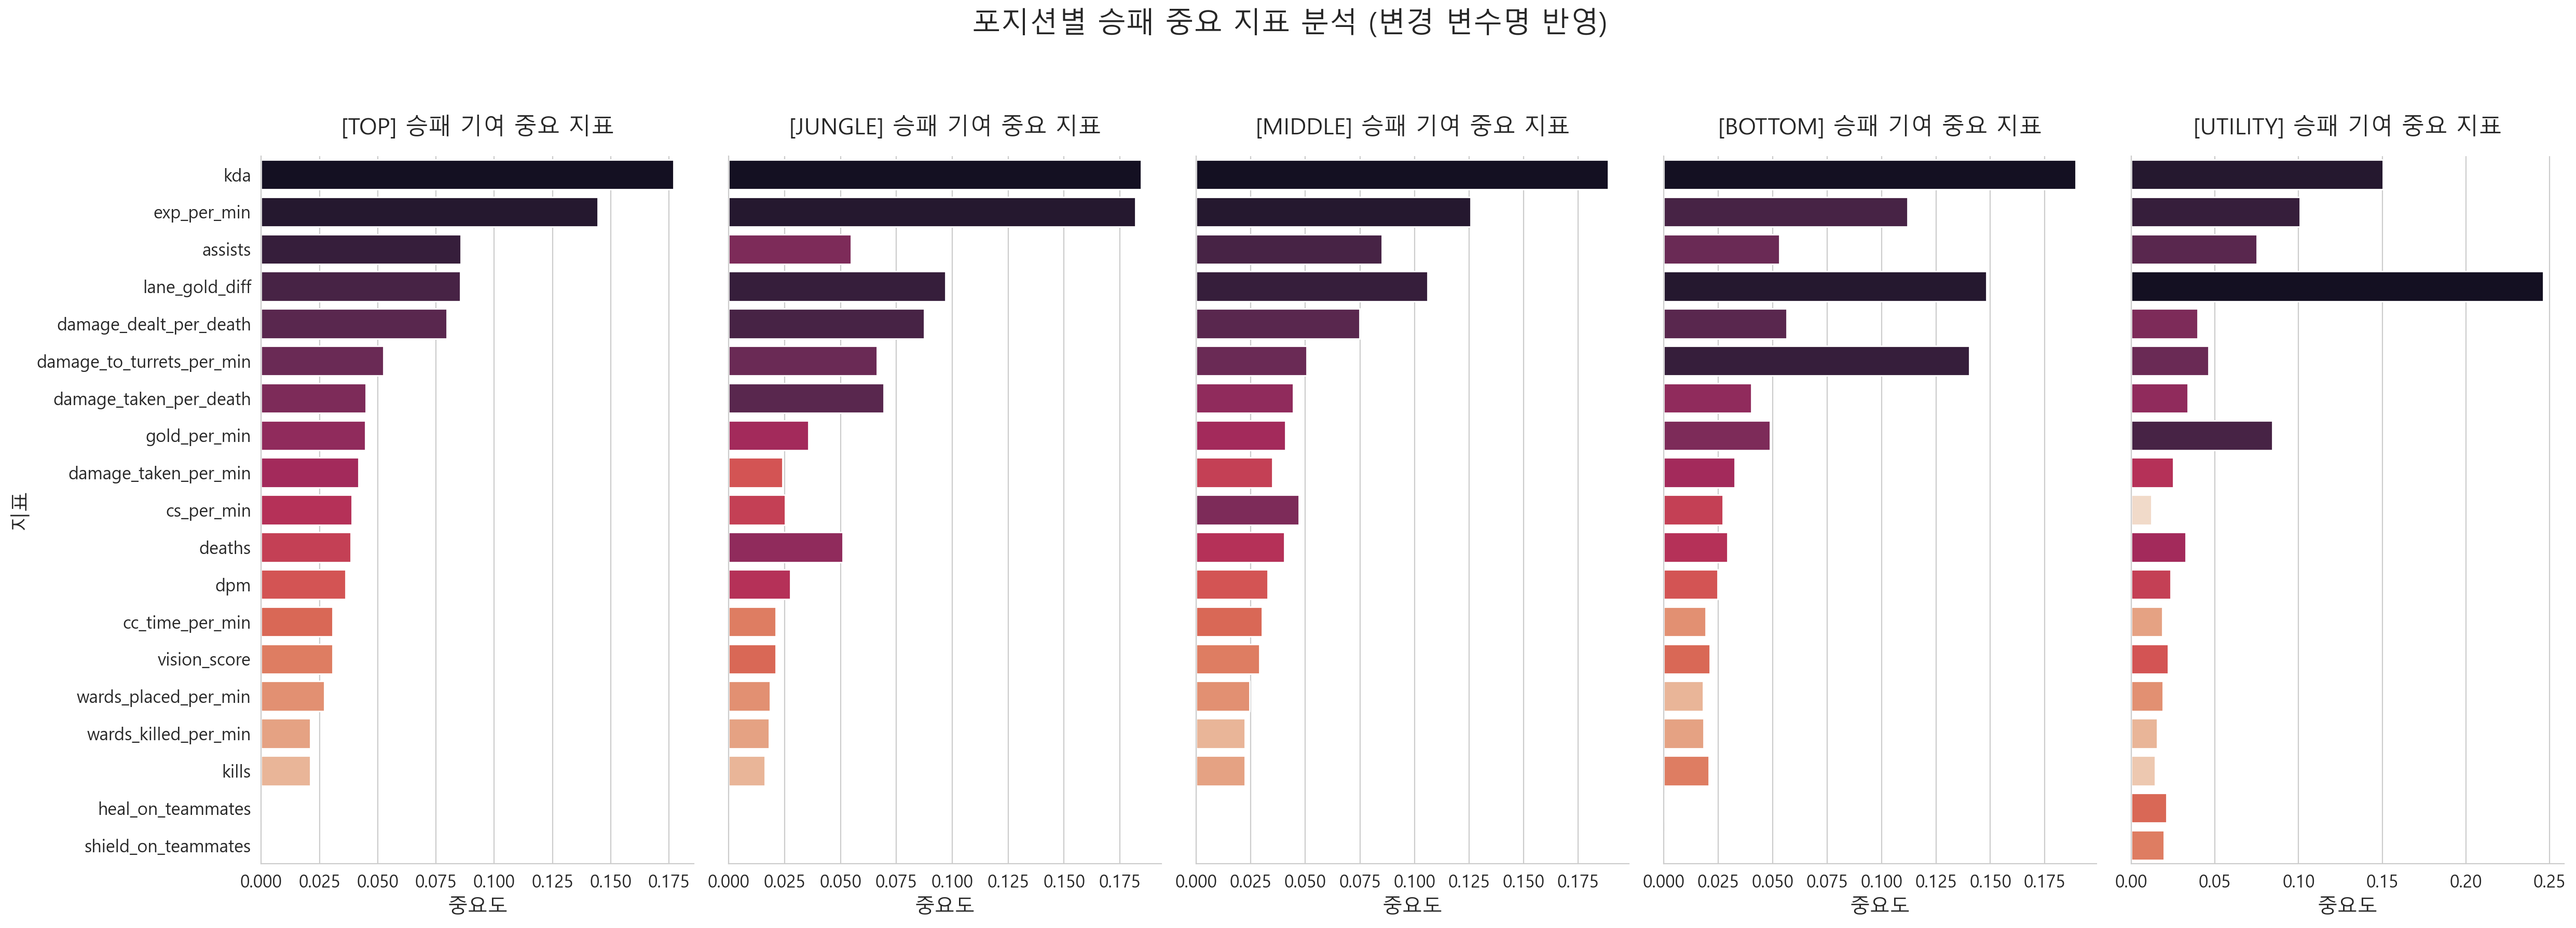

                                TOP    JUNGLE    MIDDLE    BOTTOM   UTILITY
kills                      0.021106  0.016228  0.022366  0.020637  0.014235
deaths                     0.038386  0.051125  0.040487  0.029280  0.032510
assists                    0.085654  0.054708  0.085010  0.053082  0.075134
gold_per_min               0.044790  0.035730  0.040903  0.048921  0.084254
exp_per_min                0.144377  0.182012  0.125740  0.112020  0.100864
dpm                        0.036147  0.027595  0.032805  0.024797  0.023501
damage_to_turrets_per_min  0.052437  0.066416  0.050594  0.140318  0.046158
vision_score               0.030676  0.021105  0.029036  0.021109  0.022148
damage_taken_per_min       0.041885  0.023990  0.034936  0.032737  0.025209
cs_per_min                 0.038816  0.025360  0.047093  0.027225  0.012176
kda                        0.176901  0.184366  0.188820  0.189282  0.150339
damage_taken_per_death     0.044874  0.069248  0.044452  0.040202  0.033777
damage_dealt

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import sys

# --- 사용할 지표 선택 (변경된 변수명 반영) ---
metrics = [
    'kills',
    'deaths',
    'assists',
    'gold_per_min',
    'exp_per_min',
    'dpm',
    'damage_to_turrets_per_min',
    'vision_score',
    'damage_taken_per_min',
    'cs_per_min',
    'kda',
    'damage_taken_per_death',
    'damage_dealt_per_death',
    'wards_placed_per_min',
    'wards_killed_per_min',
    'cc_time_per_min',
    'heal_on_teammates',
    'shield_on_teammates',
    'lane_gold_diff'
]

target = 'game_result'   # 1 = win, 0 = loss

# --- 스케일링 ---
scaler = StandardScaler()
df_scaled = mmr_df_cleaned_default.copy()

try:
    df_scaled[metrics] = scaler.fit_transform(df_scaled[metrics])
except KeyError as e:
    print(f"에러! 컬럼 {e} 이(가) 데이터프레임에 없습니다. metrics 리스트를 확인하세요.")
    sys.exit()

# --- 포지션별 feature importance 저장 ---
position_importances = {}

for pos in df_scaled['position'].dropna().unique():
    df_pos = df_scaled[df_scaled['position'] == pos].copy()

    X = df_pos[metrics]
    y = df_pos[target]

    if len(y.unique()) < 2 or len(df_pos) < 5:
        print(f"안내: 포지션 '{pos}'은 승패 데이터가 부족하거나 표본 수가 부족하여 분석에서 제외됩니다.")
        continue

    X = X.replace([np.inf, -np.inf], np.nan).dropna()
    y = y.loc[X.index]

    if X.shape[0] == 0:
        print(f"안내: 포지션 '{pos}'은 유효한 데이터가 없어 분석에서 제외됩니다.")
        continue

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
    model.fit(X, y)

    importances = model.feature_importances_
    position_importances[pos] = dict(zip(metrics, importances))

# --- 시각화 ---
if not position_importances:
    print("분석 가능한 포지션 데이터가 없어 그래프를 그릴 수 없습니다. 원본 데이터를 확인하세요.")
else:
    sns.set_style("whitegrid")
    plt.rcParams.update({
        'font.size': 12,
        'font.family': 'Malgun Gothic'
    })

    num_positions = len(position_importances)
    fig, axes = plt.subplots(1, num_positions, figsize=(5 * num_positions, 9), sharey=True)

    if num_positions == 1:
        axes = [axes]

    for i, (pos, imp_dict) in enumerate(position_importances.items()):
        imp_series = pd.Series(imp_dict).sort_values(ascending=False)

        sns.barplot(
            x=imp_series.values,
            y=imp_series.index,
            ax=axes[i],
            palette="rocket"
        )

        axes[i].set_title(f"[{pos}] 승패 기여 중요 지표", fontsize=16, pad=15)
        axes[i].set_xlabel("중요도", fontsize=14)
        axes[i].set_ylabel("")

        if i == 0:
            axes[i].set_ylabel("지표", fontsize=14)

        sns.despine(ax=axes[i], top=True, right=True)

    plt.suptitle("포지션별 승패 중요 지표 분석 (변경 변수명 반영)", fontsize=20, y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

# --- 결과 DataFrame ---
position_importances_df = pd.DataFrame(position_importances).fillna(0)
print(position_importances_df)

# 📈 Game Impact Score 산출

포지션별 Feature Importance를 통해 도출된 가중치를 기반으로,  
각 플레이어의 경기 내 영향력을 정량화하는 Game Impact Score를 계산하였다.

각 플레이어의 능력치는 해당 포지션의 중요도(가중치)와 결합되어  
가중합 형태로 raw_game_impact를 산출한다.

이 과정은 다음과 같은 의미를 가진다:

- 단순 지표 합이 아닌 **포지션별 중요도를 반영한 영향력 계산**
- 다양한 능력치를 하나의 **통합 퍼포먼스 지표로 변환**
- 이후 MMR 산정의 핵심 입력 변수로 활용

또한 raw_game_impact는 직관적인 해석을 위해 Min-Max Scaling을 적용하여  
0~100 범위의 점수로 정규화하였다.

이를 통해:
- 플레이어 간 퍼포먼스를 직관적으로 비교할 수 있고
- 이후 인분 지표, 상대 비교 지표, MMR 계산에 일관된 기준으로 활용 가능하다

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ------------------------------------
# 1. 포지션별 importance 결과 불러오기
# ------------------------------------
# index = feature명, columns = 포지션명 (TOP, JUNGLE, MIDDLE, BOTTOM, UTILITY)
position_importances_df = position_importances_df.copy()

# 가중치 딕셔너리로 변환
position_weights = position_importances_df.to_dict()

# ------------------------------------
# 2. 플레이어별 game_impact 계산 함수
# ------------------------------------
def calculate_game_impact(row, weights_dict):
    pos = row['position']

    if pos not in weights_dict:
        return np.nan  # 예외 처리

    weights = weights_dict[pos]  # 해당 포지션의 feature importance dict

    # feature별 값 × 가중치 → 가중합
    impact_score = 0
    for feature, weight in weights.items():
        if feature in row.index and pd.notnull(row[feature]):
            impact_score += row[feature] * weight

    return impact_score

# ------------------------------------
# 3. game_impact 계산 적용
# ------------------------------------
mmr_df_cleaned_default['raw_game_impact'] = mmr_df_cleaned_default.apply(
    lambda row: calculate_game_impact(row, position_weights),
    axis=1
)

# ------------------------------------
# 4. 정규화 (0 ~ 100 점수)
# ------------------------------------
scaler = MinMaxScaler(feature_range=(0, 100))
mmr_df_cleaned_default['game_impact'] = scaler.fit_transform(
    mmr_df_cleaned_default[['raw_game_impact']]
)

# ------------------------------------
# 5. 확인
# ------------------------------------
print(
    mmr_df_cleaned_default[['puuid', 'position', 'raw_game_impact', 'game_impact']].head(20)
)

                                   puuid position  raw_game_impact  \
0   f9ddea1d-7bd9-54a6-98aa-0c122b2bbbab      TOP       700.995167   
1   bae2876d-9787-57cd-a7ed-531726041d87   JUNGLE       -64.272246   
2   5b13638b-769a-50d8-9b25-68a606cbbb5d   MIDDLE      -248.561608   
3   24efaca6-cfb8-5860-b673-cc5c44d952ca   BOTTOM      -111.103494   
4   c1c13c35-aa88-5cb2-a28e-43bcf44124df  UTILITY      -215.938677   
5   f5a173bf-10b4-52bc-9a5d-002808b72f5e      TOP      1501.538255   
6   d96e2c4b-96c3-5089-b786-05b994f847af   JUNGLE      3057.275067   
7   60c6f4f8-34f5-5ffd-b2a4-a2e33730d642   MIDDLE      2216.631168   
8   e7ba9d3d-8d5f-5d45-8b5e-943fc25c6b76   BOTTOM      2471.917480   
9   241fe26c-57e7-5481-9f4e-ad52521eb3bc  UTILITY      1790.011596   
10  f9ddea1d-7bd9-54a6-98aa-0c122b2bbbab      TOP       744.823155   
11  5b13638b-769a-50d8-9b25-68a606cbbb5d   JUNGLE       417.338366   
12  c1c13c35-aa88-5cb2-a28e-43bcf44124df   MIDDLE       193.271243   
13  f5a173bf-10b4-52

In [10]:
mmr_df_cleaned_default.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18500 entries, 0 to 18499
Data columns (total 77 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18500 non-null  int64  
 1   guild_id                   18500 non-null  int64  
 2   replay_code                18500 non-null  object 
 3   puuid                      18500 non-null  object 
 4   champion_id                18500 non-null  object 
 5   position                   18500 non-null  object 
 6   team                       18500 non-null  int64  
 7   game_duration              18500 non-null  float64
 8   kills                      18500 non-null  int64  
 9   deaths                     18500 non-null  int64  
 10  assists                    18500 non-null  int64  
 11  double_kills               18500 non-null  int64  
 12  triple_kills               18500 non-null  int64  
 13  quadra_kills               18500 non-null  int

## 📊 Game Impact Score 분포 정규화

포지션별로 산출된 raw_game_impact는 데이터 분포의 왜도와 첨도 차이로 인해  
포지션 간 직접 비교가 어려운 문제가 존재한다.

예를 들어:
- 특정 포지션은 점수가 한쪽으로 치우쳐 있을 수 있고
- 다른 포지션은 분산이 크게 나타날 수 있어  
동일 점수라도 실제 의미가 달라질 수 있다.

이를 해결하기 위해 본 프로젝트에서는 각 포지션별로  
Quantile Transformation을 적용하여 점수를 정규분포에 가깝게 변환하였다.

이후 Min-Max Scaling을 통해 0~100 범위로 재정규화하여  
최종 Game Impact Score를 산출하였다.

이 과정을 통해:
- 포지션 간 점수 분포 차이를 보정하고
- 동일 점수에 대한 해석 기준을 통일하며
- 공정한 비교가 가능한 평가 체계를 구축하였다

### 포지션 별 정규분포 확인

--- 정규 분포에 가깝게 변환된 game_impact 점수 (상위 20개) ---
                                   puuid position  raw_game_impact  \
0   f9ddea1d-7bd9-54a6-98aa-0c122b2bbbab      TOP       700.995167   
1   bae2876d-9787-57cd-a7ed-531726041d87   JUNGLE       -64.272246   
2   5b13638b-769a-50d8-9b25-68a606cbbb5d   MIDDLE      -248.561608   
3   24efaca6-cfb8-5860-b673-cc5c44d952ca   BOTTOM      -111.103494   
4   c1c13c35-aa88-5cb2-a28e-43bcf44124df  UTILITY      -215.938677   
5   f5a173bf-10b4-52bc-9a5d-002808b72f5e      TOP      1501.538255   
6   d96e2c4b-96c3-5089-b786-05b994f847af   JUNGLE      3057.275067   
7   60c6f4f8-34f5-5ffd-b2a4-a2e33730d642   MIDDLE      2216.631168   
8   e7ba9d3d-8d5f-5d45-8b5e-943fc25c6b76   BOTTOM      2471.917480   
9   241fe26c-57e7-5481-9f4e-ad52521eb3bc  UTILITY      1790.011596   
10  f9ddea1d-7bd9-54a6-98aa-0c122b2bbbab      TOP       744.823155   
11  5b13638b-769a-50d8-9b25-68a606cbbb5d   JUNGLE       417.338366   
12  c1c13c35-aa88-5cb2-a28e-43bcf44124df   

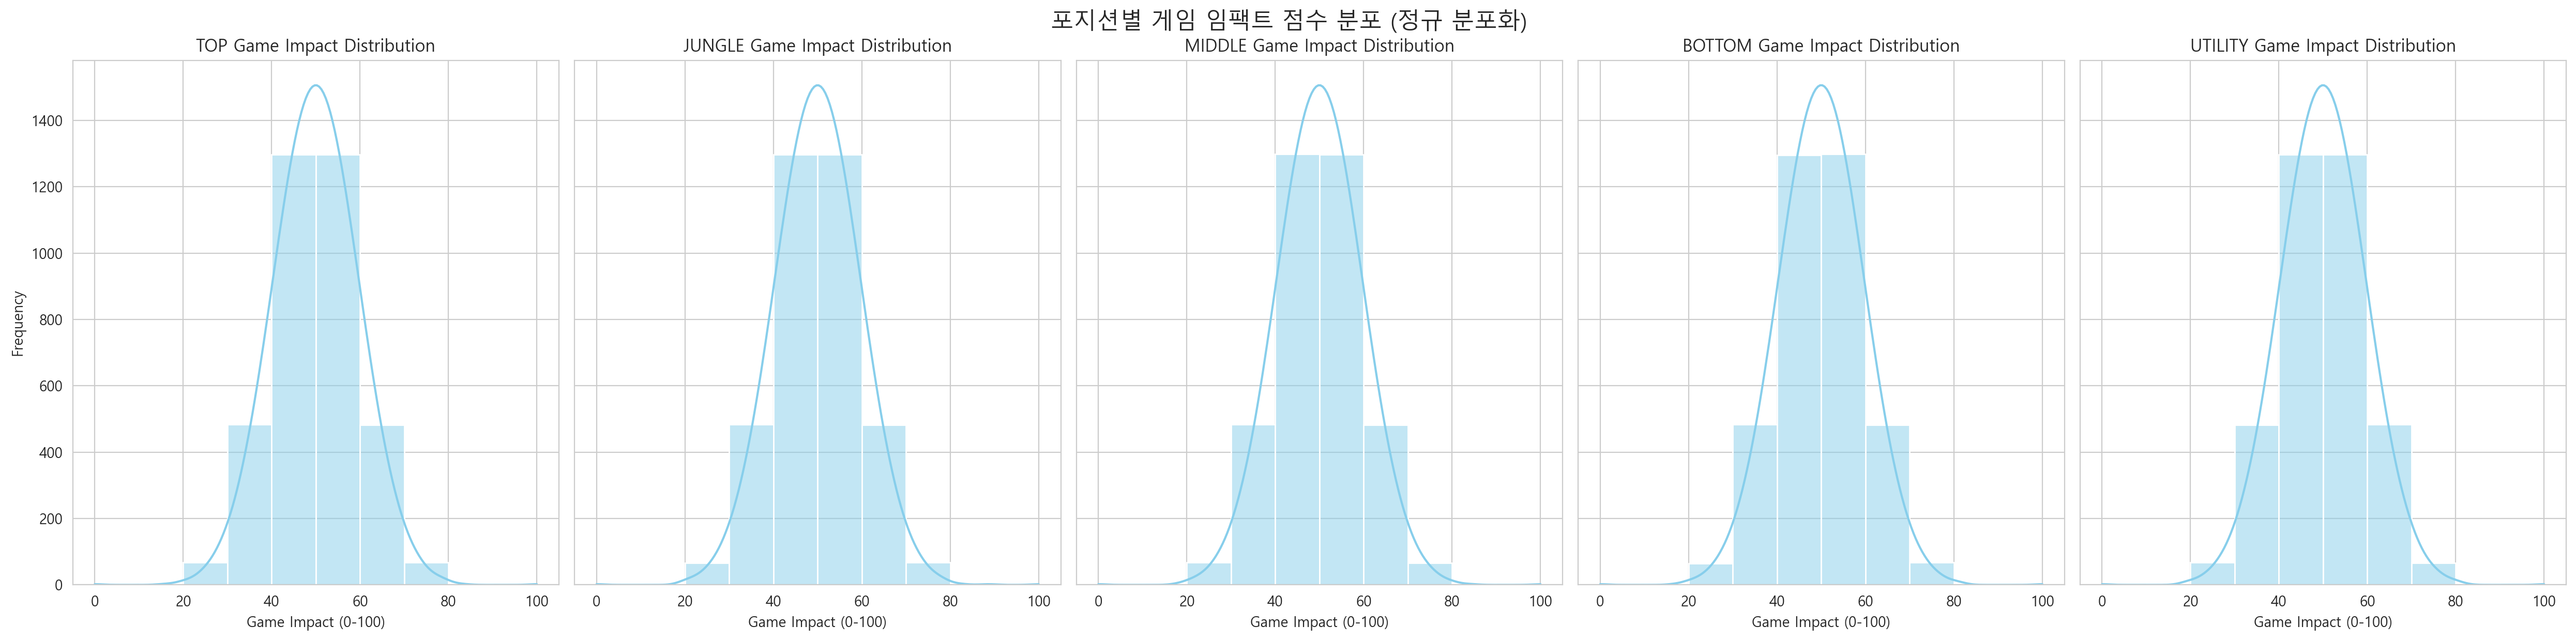


--- 각 포지션별 game_impact_normal_dist의 왜도(Skewness)와 첨도(Kurtosis) ---
[TOP] Skewness: -0.0031, Kurtosis: 0.2684
[JUNGLE] Skewness: 0.0084, Kurtosis: 0.2782
[MIDDLE] Skewness: 0.0025, Kurtosis: 0.2563
[BOTTOM] Skewness: -0.0007, Kurtosis: 0.2557
[UTILITY] Skewness: -0.0005, Kurtosis: 0.2485


In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------
# 3. 각 포지션별로 정규 분포에 가깝게 변환 후 0 ~ 100 점수로 정규화
# ------------------------------------
mmr_df_cleaned_default['game_impact_normal_dist'] = np.nan

unique_positions = mmr_df_cleaned_default['position'].dropna().unique()

# 폰트 설정
plt.rcParams.update({'font.size': 10, 'font.family': 'Malgun Gothic'})
# macOS/Linux 사용자는 필요 시 아래로 변경
# plt.rcParams['font.family'] = 'AppleGothic'
# plt.rcParams['font.family'] = 'NanumGothic'

for pos in unique_positions:
    # 해당 포지션 데이터만 필터링
    pos_data_idx = mmr_df_cleaned_default['position'] == pos
    pos_impact_data = mmr_df_cleaned_default.loc[
        pos_data_idx, 'raw_game_impact'
    ].values.reshape(-1, 1)

    # NaN / Inf 제거
    pos_impact_data = pos_impact_data[
        ~np.isnan(pos_impact_data) & ~np.isinf(pos_impact_data)
    ]

    # 데이터가 너무 적으면 스킵
    if len(pos_impact_data) < 2:
        print(f"경고: '{pos}' 포지션의 데이터가 부족하여 정규 분포 변환을 스킵합니다.")
        continue

    # 1. 정규분포에 가깝게 변환
    n_quantiles_val = min(len(pos_impact_data), 1000)

    qt_scaler = QuantileTransformer(
        output_distribution='normal',
        random_state=42,
        n_quantiles=n_quantiles_val
    )
    transformed_data = qt_scaler.fit_transform(pos_impact_data.reshape(-1, 1))

    # 2. 0~100 점수로 스케일링
    mm_scaler = MinMaxScaler(feature_range=(0, 100))
    final_scaled_data = mm_scaler.fit_transform(transformed_data)

    # 원본 DataFrame에 저장
    mmr_df_cleaned_default.loc[
        pos_data_idx, 'game_impact_normal_dist'
    ] = final_scaled_data.flatten()

# ------------------------------------
# 4. 확인 및 분포 시각화
# ------------------------------------
print("--- 정규 분포에 가깝게 변환된 game_impact 점수 (상위 20개) ---")
print(
    mmr_df_cleaned_default[
        ['puuid', 'position', 'raw_game_impact', 'game_impact_normal_dist']
    ].head(20)
)

print("\n--- 각 포지션별 game_impact_normal_dist 분포 시각화 ---")

if len(unique_positions) == 0:
    print("분석할 포지션 데이터가 없어 분포 그래프를 그릴 수 없습니다.")
else:
    fig, axes = plt.subplots(
        1,
        len(unique_positions),
        figsize=(5 * len(unique_positions), 6),
        sharey=True
    )

    if len(unique_positions) == 1:
        axes = [axes]

    for i, pos in enumerate(unique_positions):
        plot_data = mmr_df_cleaned_default[
            mmr_df_cleaned_default['position'] == pos
        ]['game_impact_normal_dist'].dropna()

        if not plot_data.empty:
            sns.histplot(plot_data, kde=True, ax=axes[i], bins=10, color='skyblue')
            axes[i].set_title(f'{pos} Game Impact Distribution')
            axes[i].set_xlabel('Game Impact (0-100)')
            axes[i].set_ylabel('Frequency')
        else:
            axes[i].set_title(f'{pos} No Data')
            axes[i].set_xlabel('Game Impact (0-100)')
            axes[i].set_ylabel('Frequency')

    plt.tight_layout()
    plt.suptitle("포지션별 게임 임팩트 점수 분포 (정규 분포화)", fontsize=16, y=1.02)
    plt.show()

# ------------------------------------
# 5. 왜도 / 첨도 확인
# ------------------------------------
print("\n--- 각 포지션별 game_impact_normal_dist의 왜도(Skewness)와 첨도(Kurtosis) ---")
for pos in unique_positions:
    data_for_stats = mmr_df_cleaned_default[
        mmr_df_cleaned_default['position'] == pos
    ]['game_impact_normal_dist'].dropna()

    if len(data_for_stats) > 1:
        print(f"[{pos}] Skewness: {data_for_stats.skew():.4f}, Kurtosis: {data_for_stats.kurt():.4f}")
    else:
        print(f"[{pos}] 데이터 부족으로 왜도/첨도 계산 불가.")

### 📊 승패 조건을 반영한 Game Impact Score 정규화

포지션별 정규화 이후에도, 동일한 Game Impact Score라도  
승리와 패배 상황에서 그 의미가 달라질 수 있는 문제가 존재한다.

예를 들어:
- 승리한 게임에서는 전체적으로 높은 퍼포먼스가 나타나는 경향이 있고
- 패배한 게임에서는 상대적으로 낮은 분포를 가지게 된다

이 상태에서 동일한 기준으로 비교할 경우:
- 패배팀 내 높은 퍼포먼스가 과소평가되거나
- 승리팀 내 평균적인 퍼포먼스가 과대평가될 수 있다

이를 해결하기 위해 본 프로젝트에서는  
포지션뿐만 아니라 **승리/패배 조건까지 분리하여**  
Game Impact Score를 정규분포에 가깝게 변환하였다.

이후 0~100 범위로 재정규화하여  
최종적으로 **game_impact_winloss_norm** 지표를 생성하였다.

이를 통해:
- 동일 포지션 내에서도 공정한 비교 기준을 확보하고
- 패배 경기에서도 높은 퍼포먼스를 적절히 반영하며
- 승패에 종속되지 않는 순수 퍼포먼스 평가가 가능해졌다

✨ Part 1: 승/패 별 game_impact 정규 분포화 진행 중...

--- Part 1: 승/패 별 game_impact_winloss_norm 결과 (상위 20개) ---
                                   puuid position  game_result  \
0   f9ddea1d-7bd9-54a6-98aa-0c122b2bbbab      TOP            0   
1   bae2876d-9787-57cd-a7ed-531726041d87   JUNGLE            0   
2   5b13638b-769a-50d8-9b25-68a606cbbb5d   MIDDLE            0   
3   24efaca6-cfb8-5860-b673-cc5c44d952ca   BOTTOM            0   
4   c1c13c35-aa88-5cb2-a28e-43bcf44124df  UTILITY            0   
5   f5a173bf-10b4-52bc-9a5d-002808b72f5e      TOP            1   
6   d96e2c4b-96c3-5089-b786-05b994f847af   JUNGLE            1   
7   60c6f4f8-34f5-5ffd-b2a4-a2e33730d642   MIDDLE            1   
8   e7ba9d3d-8d5f-5d45-8b5e-943fc25c6b76   BOTTOM            1   
9   241fe26c-57e7-5481-9f4e-ad52521eb3bc  UTILITY            1   
10  f9ddea1d-7bd9-54a6-98aa-0c122b2bbbab      TOP            0   
11  5b13638b-769a-50d8-9b25-68a606cbbb5d   JUNGLE            0   
12  c1c13c35-aa88-5cb2-a28e-43bcf44124d

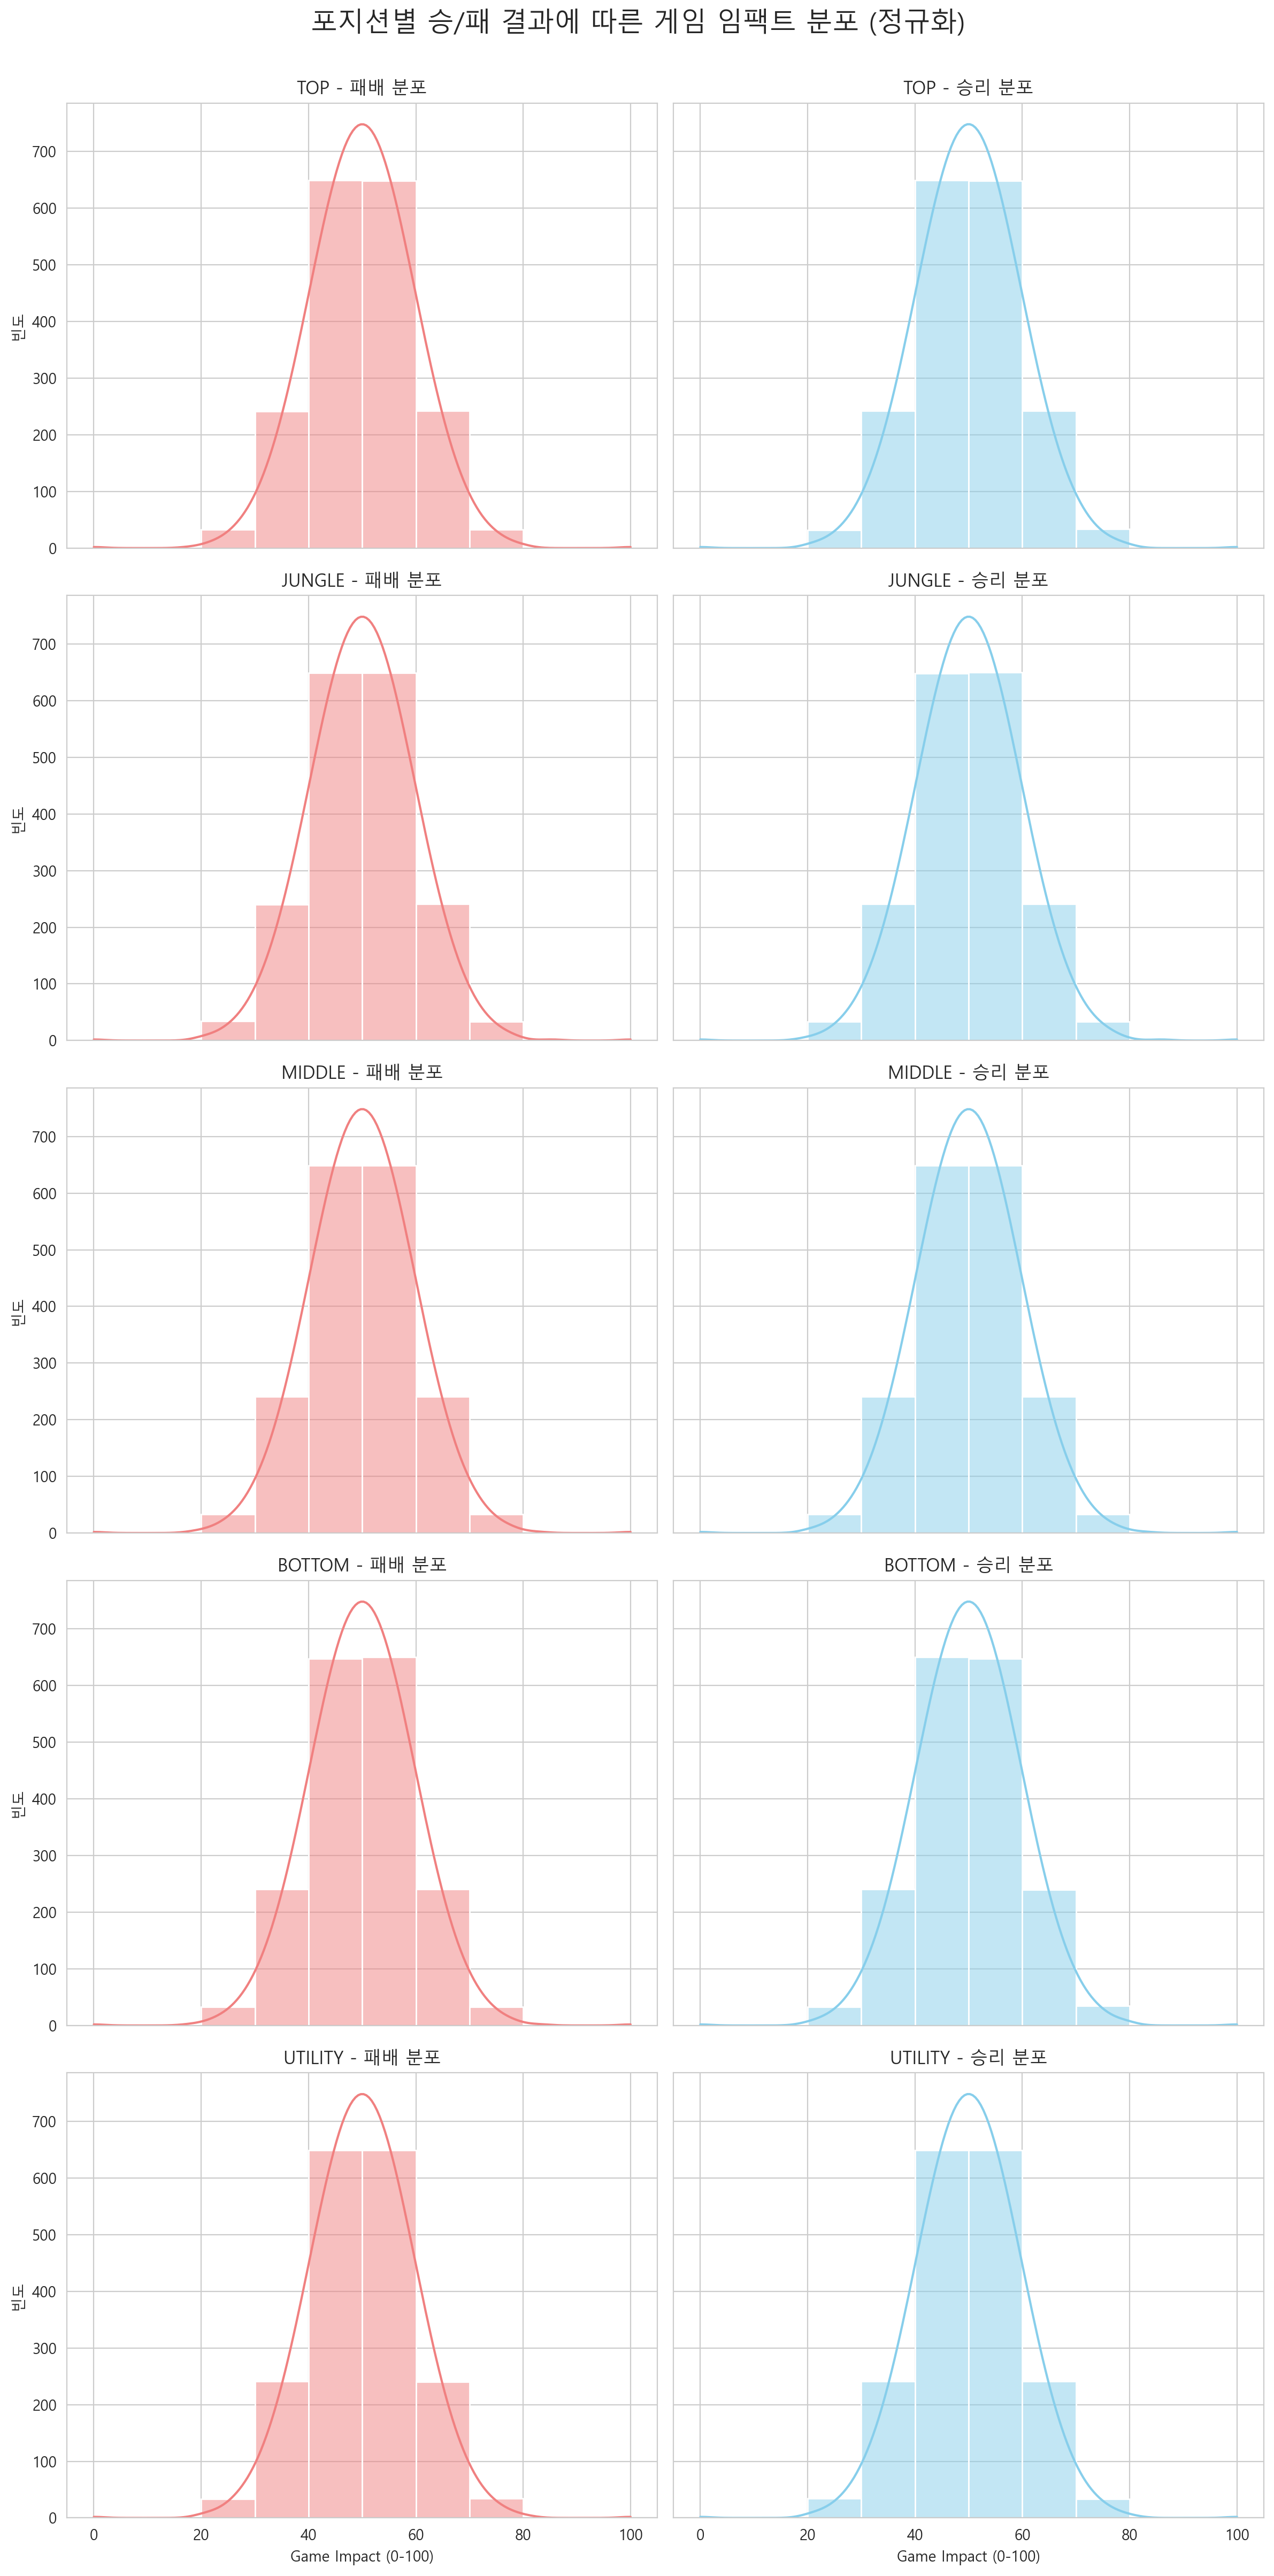


--- Part 1: 각 포지션별 승/패 game_impact_winloss_norm의 왜도(Skewness)와 첨도(Kurtosis) ---
[TOP - 패배] Skewness: -0.0033, Kurtosis: 0.5272
[TOP - 승리] Skewness: -0.0011, Kurtosis: 0.5198
[JUNGLE - 패배] Skewness: 0.0070, Kurtosis: 0.5526
[JUNGLE - 승리] Skewness: 0.0086, Kurtosis: 0.5561
[MIDDLE - 패배] Skewness: 0.0018, Kurtosis: 0.5387
[MIDDLE - 승리] Skewness: 0.0043, Kurtosis: 0.5338
[BOTTOM - 패배] Skewness: 0.0009, Kurtosis: 0.5419
[BOTTOM - 승리] Skewness: 0.0002, Kurtosis: 0.5211
[UTILITY - 패배] Skewness: 0.0007, Kurtosis: 0.5261
[UTILITY - 승리] Skewness: 0.0011, Kurtosis: 0.5253


In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------
# 1. 승리 / 패배로 나누어 game_impact 정규 분포화
#    'game_impact_winloss_norm'라는 새로운 컬럼에 저장
# ----------------------------------------------------
print("✨ Part 1: 승/패 별 game_impact 정규 분포화 진행 중...")
mmr_df_cleaned_default['game_impact_winloss_norm'] = np.nan

unique_positions = mmr_df_cleaned_default['position'].dropna().unique()
game_results = mmr_df_cleaned_default['game_result'].dropna().unique()  # 승(1), 패(0)

# 각 포지션별, 승/패 결과별로 반복
for pos in unique_positions:
    for result in game_results:
        # 해당 포지션 & 승/패 데이터만 필터링
        condition = (
            (mmr_df_cleaned_default['position'] == pos) &
            (mmr_df_cleaned_default['game_result'] == result)
        )

        pos_result_data_idx = mmr_df_cleaned_default.loc[condition].index

        # 필터링된 데이터가 없으면 건너뛰기
        if pos_result_data_idx.empty:
            continue

        pos_impact_data = mmr_df_cleaned_default.loc[
            pos_result_data_idx, 'raw_game_impact'
        ].values

        # NaN / Inf 제거
        pos_impact_data = pos_impact_data[
            ~np.isnan(pos_impact_data) & ~np.isinf(pos_impact_data)
        ]

        # 데이터가 너무 적으면 스킵
        if len(pos_impact_data) < 2:
            print(f"✨ 경고: '{pos}' 포지션, {'승리' if result == 1 else '패배'} 데이터가 부족하여 정규 분포 변환을 스킵합니다.")
            continue

        # 1. QuantileTransformer로 정규 분포에 가깝게 변환
        n_quantiles_val = min(len(pos_impact_data), 1000)
        qt_scaler = QuantileTransformer(
            output_distribution='normal',
            random_state=42,
            n_quantiles=n_quantiles_val
        )
        transformed_data = qt_scaler.fit_transform(pos_impact_data.reshape(-1, 1))

        # 2. MinMaxScaler로 0~100 점수화
        mm_scaler = MinMaxScaler(feature_range=(0, 100))
        final_scaled_data = mm_scaler.fit_transform(transformed_data)

        # 결과 저장
        mmr_df_cleaned_default.loc[
            pos_result_data_idx, 'game_impact_winloss_norm'
        ] = final_scaled_data.flatten()

print("\n--- Part 1: 승/패 별 game_impact_winloss_norm 결과 (상위 20개) ---")
print(
    mmr_df_cleaned_default[
        ['puuid', 'position', 'game_result', 'raw_game_impact', 'game_impact_winloss_norm']
    ].head(20)
)

# ----------------------------------------------------
# 2. 분포 시각화
# ----------------------------------------------------
print("\n--- Part 1: 각 포지션별 승/패 game_impact_winloss_norm 분포 시각화 ---")

if len(unique_positions) == 0 or len(game_results) == 0:
    print("분석할 포지션 또는 승패 데이터가 없어 그래프를 그릴 수 없습니다.")
else:
    fig, axes = plt.subplots(
        len(unique_positions),
        len(game_results),
        figsize=(6 * len(game_results), 5 * len(unique_positions)),
        sharex=True,
        sharey=True
    )

    if len(unique_positions) == 1 and len(game_results) == 1:
        axes = np.array([[axes]])
    elif len(unique_positions) == 1:
        axes = np.expand_dims(axes, axis=0)
    elif len(game_results) == 1:
        axes = np.expand_dims(axes, axis=1)

    for i, pos in enumerate(unique_positions):
        for j, result in enumerate(game_results):
            ax = axes[i, j]

            plot_data = mmr_df_cleaned_default[
                (mmr_df_cleaned_default['position'] == pos) &
                (mmr_df_cleaned_default['game_result'] == result)
            ]['game_impact_winloss_norm'].dropna()

            title_result = '승리' if result == 1 else '패배'

            if not plot_data.empty:
                sns.histplot(
                    plot_data,
                    kde=True,
                    bins=10,
                    ax=ax,
                    color='lightcoral' if result == 0 else 'skyblue'
                )
                ax.set_title(f'{pos} - {title_result} 분포')
                ax.set_xlabel('Game Impact (0-100)')
                ax.set_ylabel('빈도')
            else:
                ax.set_title(f'{pos} - {title_result} (데이터 없음)')
                ax.set_xlabel('')
                ax.set_ylabel('')

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.suptitle("포지션별 승/패 결과에 따른 게임 임팩트 분포 (정규화)", fontsize=18, y=0.99)
    plt.show()

# ----------------------------------------------------
# 3. 왜도 / 첨도 확인
# ----------------------------------------------------
print("\n--- Part 1: 각 포지션별 승/패 game_impact_winloss_norm의 왜도(Skewness)와 첨도(Kurtosis) ---")
for pos in unique_positions:
    for result in game_results:
        data_for_stats = mmr_df_cleaned_default[
            (mmr_df_cleaned_default['position'] == pos) &
            (mmr_df_cleaned_default['game_result'] == result)
        ]['game_impact_winloss_norm'].dropna()

        title_result = '승리' if result == 1 else '패배'

        if len(data_for_stats) > 1:
            print(f"[{pos} - {title_result}] Skewness: {data_for_stats.skew():.4f}, Kurtosis: {data_for_stats.kurt():.4f}")
        else:
            print(f"[{pos} - {title_result}] 데이터 부족으로 왜도/첨도 계산 불가.")

### 포지션별 정규화 결과 검증

포지션 및 승패 기준으로 정규화된 `game_impact_winloss_norm` 점수가  
실제로 포지션 간 비교 가능한 형태로 보정되었는지 확인하기 위해  
추가적인 분포 검증을 수행하였다.

이 단계에서는 포지션별로 평균, 중앙값, 표준편차, 최소/최대값을 확인하고,  
Violin Plot과 Box Plot을 활용하여 각 포지션의 점수 분포 형태를 비교하였다.

이 검증이 필요한 이유는 다음과 같다:

- 정규화 이후에도 특정 포지션의 점수가 한쪽으로 치우쳐 있을 수 있음
- 포지션별 분포 차이가 남아 있다면 동일 점수의 의미가 달라질 수 있음
- 이후 인분 지표, 상대 비교 지표, MMR 산정에 왜곡이 발생할 수 있음

따라서 본 단계는 단순 시각화가 아니라,
정규화된 Game Impact Score가 실제로 포지션 간 공정한 비교 기준으로 작동하는지 점검하는 과정이다.

이를 통해:
- 포지션별 점수 분포의 균형 여부를 확인하고
- 정규화 로직의 타당성을 검증하며
- 최종 MMR 산정 지표의 신뢰도를 높일 수 있었다


✨ Part 2: 포지션별 game_impact 균등성 확인 중...

--- Part 2: 포지션별 'game_impact_winloss_norm' 주요 통계 ---
          count       mean     median       std  min    max
position                                                   
JUNGLE     3700  50.002324  50.003532  9.723571  0.0  100.0
MIDDLE     3700  50.001120  49.999937  9.718632  0.0  100.0
UTILITY    3700  50.000357  50.002343  9.715702  0.0  100.0
BOTTOM     3700  50.000030  49.999122  9.716538  0.0  100.0
TOP        3700  49.998904  49.999930  9.714304  0.0  100.0

--- Part 2: 포지션별 game_impact_winloss_norm 분포 Violin Plot ---


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18020\2632915802.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


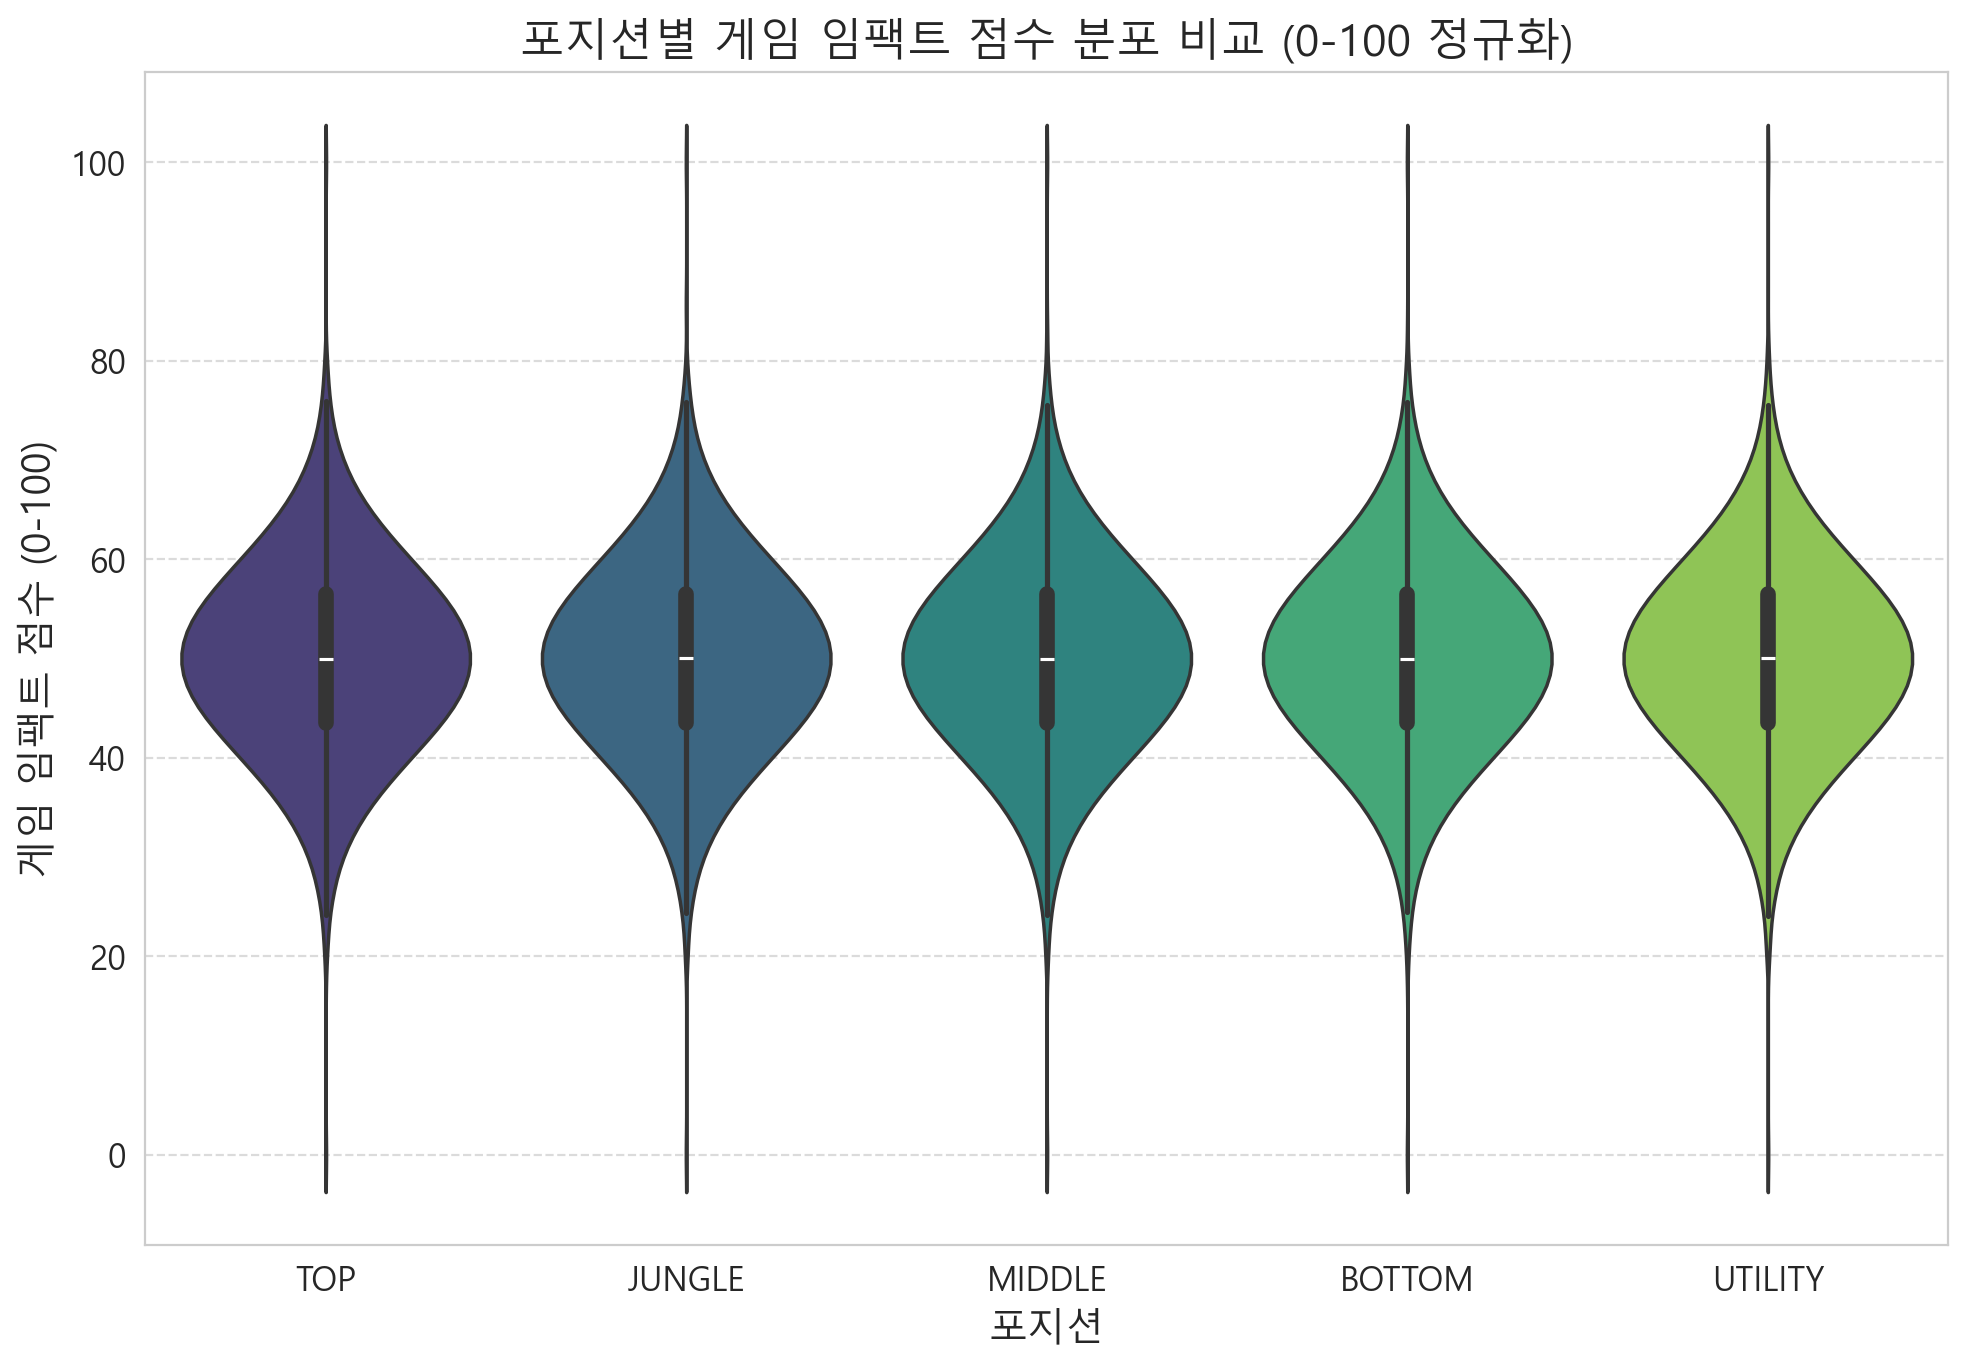


--- Part 2: 포지션별 game_impact_winloss_norm 분포 Box Plot (참고용) ---


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18020\2632915802.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


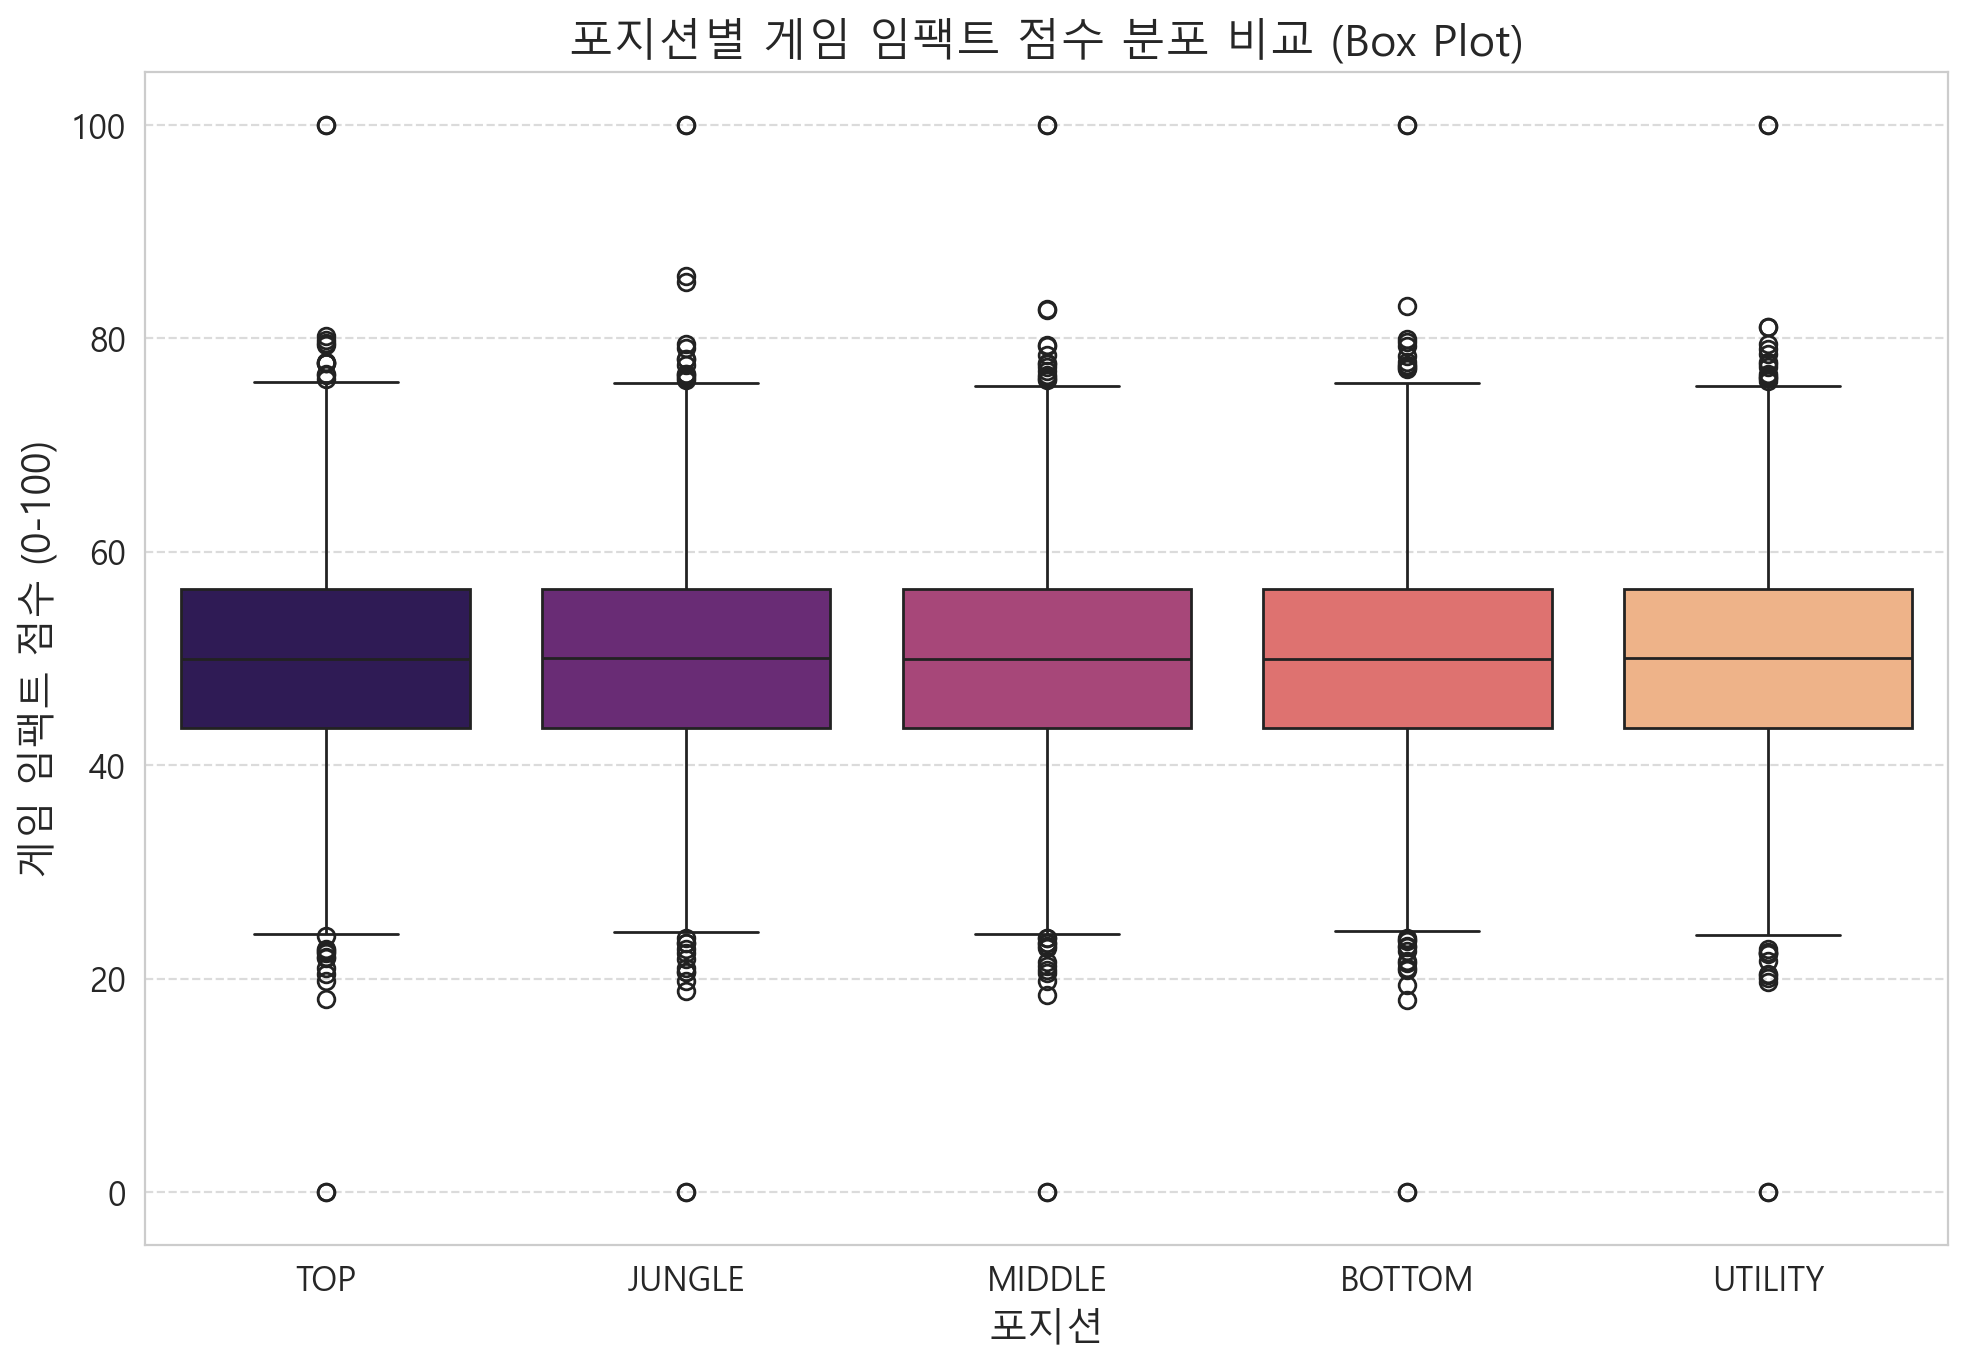

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 폰트 설정 (시각화 시 한글 깨짐 방지)
plt.rcParams.update({'font.size': 12, 'font.family': 'Malgun Gothic'})
# macOS/Linux 사용자는 필요 시 아래로 변경
# plt.rcParams['font.family'] = 'AppleGothic'
# plt.rcParams['font.family'] = 'NanumGothic'

# ----------------------------------------------------
# 2. 포지션별 game_impact 균등성 확인
#    (Part 1에서 계산된 'game_impact_winloss_norm' 컬럼 사용)
# ----------------------------------------------------
print("\n✨ Part 2: 포지션별 game_impact 균등성 확인 중...")

# 필요한 데이터만 필터링 (NaN 값 제외)
plot_data_for_uniformity = mmr_df_cleaned_default[
    ['position', 'game_impact_winloss_norm']
].dropna()

if plot_data_for_uniformity.empty:
    print("😢 'game_impact_winloss_norm' 데이터가 없어 포지션별 균등성을 확인할 수 없습니다.")
else:
    # 1. 포지션별 평균/중앙값 등 주요 통계 확인
    print("\n--- Part 2: 포지션별 'game_impact_winloss_norm' 주요 통계 ---")
    position_stats = plot_data_for_uniformity.groupby('position')['game_impact_winloss_norm'].agg(
        ['count', 'mean', 'median', 'std', 'min', 'max']
    ).sort_values(by='mean', ascending=False)
    print(position_stats)

    # 2. Violin Plot으로 포지션별 분포 비교
    print("\n--- Part 2: 포지션별 game_impact_winloss_norm 분포 Violin Plot ---")
    plt.figure(figsize=(10, 7))
    sns.violinplot(
        x='position',
        y='game_impact_winloss_norm',
        data=plot_data_for_uniformity,
        palette='viridis'
    )
    plt.title('포지션별 게임 임팩트 점수 분포 비교 (0-100 정규화)', fontsize=16)
    plt.xlabel('포지션', fontsize=14)
    plt.ylabel('게임 임팩트 점수 (0-100)', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 3. Box Plot으로 포지션별 분포 비교
    print("\n--- Part 2: 포지션별 game_impact_winloss_norm 분포 Box Plot (참고용) ---")
    plt.figure(figsize=(10, 7))
    sns.boxplot(
        x='position',
        y='game_impact_winloss_norm',
        data=plot_data_for_uniformity,
        palette='magma'
    )
    plt.title('포지션별 게임 임팩트 점수 분포 비교 (Box Plot)', fontsize=16)
    plt.xlabel('포지션', fontsize=14)
    plt.ylabel('게임 임팩트 점수 (0-100)', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 📊 팀 내 기여도 및 상대 비교 지표 설계

단순한 Game Impact Score만으로는 플레이어의 퍼포먼스를 충분히 설명하기 어렵다.  
같은 점수를 기록하더라도, 팀 내에서 얼마나 큰 비중을 차지했는지와  
동일 포지션 상대와 비교했을 때 얼마나 우위에 있었는지는 별도로 확인할 필요가 있다.

이를 보완하기 위해 본 프로젝트에서는 두 가지 추가 지표를 설계하였다.

## 1. game_n_person_contribution (인분 지표)

각 경기에서 모든 플레이어의 `game_impact_winloss_norm` 합계를 기준으로  
개인이 차지하는 비율을 계산하고, 이를 10인 게임 구조에 맞게 환산하여  
`game_n_person_contribution` 지표를 생성하였다.

이 지표는 다음과 같은 의미를 가진다:

- 한 경기에서 팀 내 기여도를 직관적으로 해석 가능
- 단순 승패가 아닌, 팀 전체 퍼포먼스 대비 개인 비중 확인 가능
- “이 경기에서 몇 인분을 했는가”를 정량적으로 표현

이를 통해 같은 승리팀 내에서도
누가 실제로 더 큰 기여를 했는지 구분할 수 있다.

## 2. game_impact_vs_opponent (상대 비교 지표)

동일 경기, 동일 포지션에서 맞붙은 승리 팀 플레이어와 패배 팀 플레이어를 매칭한 뒤,  
두 플레이어의 `game_impact_winloss_norm` 합 대비 개인 비율을 계산하여  
`game_impact_vs_opponent` 지표를 생성하였다.

이 지표는 다음과 같은 의미를 가진다:

- 동일 포지션 상대와의 직접적인 경쟁력 반영
- 라인전 또는 역할 수행 측면에서의 상대 우위 확인 가능
- 팀 결과와 별개로, 상대 대비 퍼포먼스를 정량적으로 표현

이를 통해 단순히 팀이 이겼는지가 아니라,  
같은 포지션 상대보다 얼마나 더 높은 영향력을 보였는지 평가할 수 있다.

## 설계 의의

이 두 지표를 통해 본 프로젝트는
- 팀 내 기여도
- 상대 포지션 대비 경쟁력
을 분리하여 해석할 수 있게 되었으며,

이후 MMR 산정 과정에서 단순 승패가 아닌  
보다 정교한 퍼포먼스 기반 보정이 가능해졌다.


✨ 1. '몇 인분' 컬럼 (게임 전체 기여도, 총 합 10인분) 계산 중...

--- '몇 인분' 컬럼 샘플 (game_n_person_contribution) ---
                  replay_code                                 puuid position  \
0   RPY-260108-1t_0108_2009-2  f9ddea1d-7bd9-54a6-98aa-0c122b2bbbab      TOP   
8   RPY-260108-1t_0108_2009-2  e7ba9d3d-8d5f-5d45-8b5e-943fc25c6b76   BOTTOM   
7   RPY-260108-1t_0108_2009-2  60c6f4f8-34f5-5ffd-b2a4-a2e33730d642   MIDDLE   
6   RPY-260108-1t_0108_2009-2  d96e2c4b-96c3-5089-b786-05b994f847af   JUNGLE   
5   RPY-260108-1t_0108_2009-2  f5a173bf-10b4-52bc-9a5d-002808b72f5e      TOP   
9   RPY-260108-1t_0108_2009-2  241fe26c-57e7-5481-9f4e-ad52521eb3bc  UTILITY   
3   RPY-260108-1t_0108_2009-2  24efaca6-cfb8-5860-b673-cc5c44d952ca   BOTTOM   
2   RPY-260108-1t_0108_2009-2  5b13638b-769a-50d8-9b25-68a606cbbb5d   MIDDLE   
1   RPY-260108-1t_0108_2009-2  bae2876d-9787-57cd-a7ed-531726041d87   JUNGLE   
4   RPY-260108-1t_0108_2009-2  c1c13c35-aa88-5cb2-a28e-43bcf44124df  UTILITY   
18  RPY-260108-1t_0108_

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18020\3251770155.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


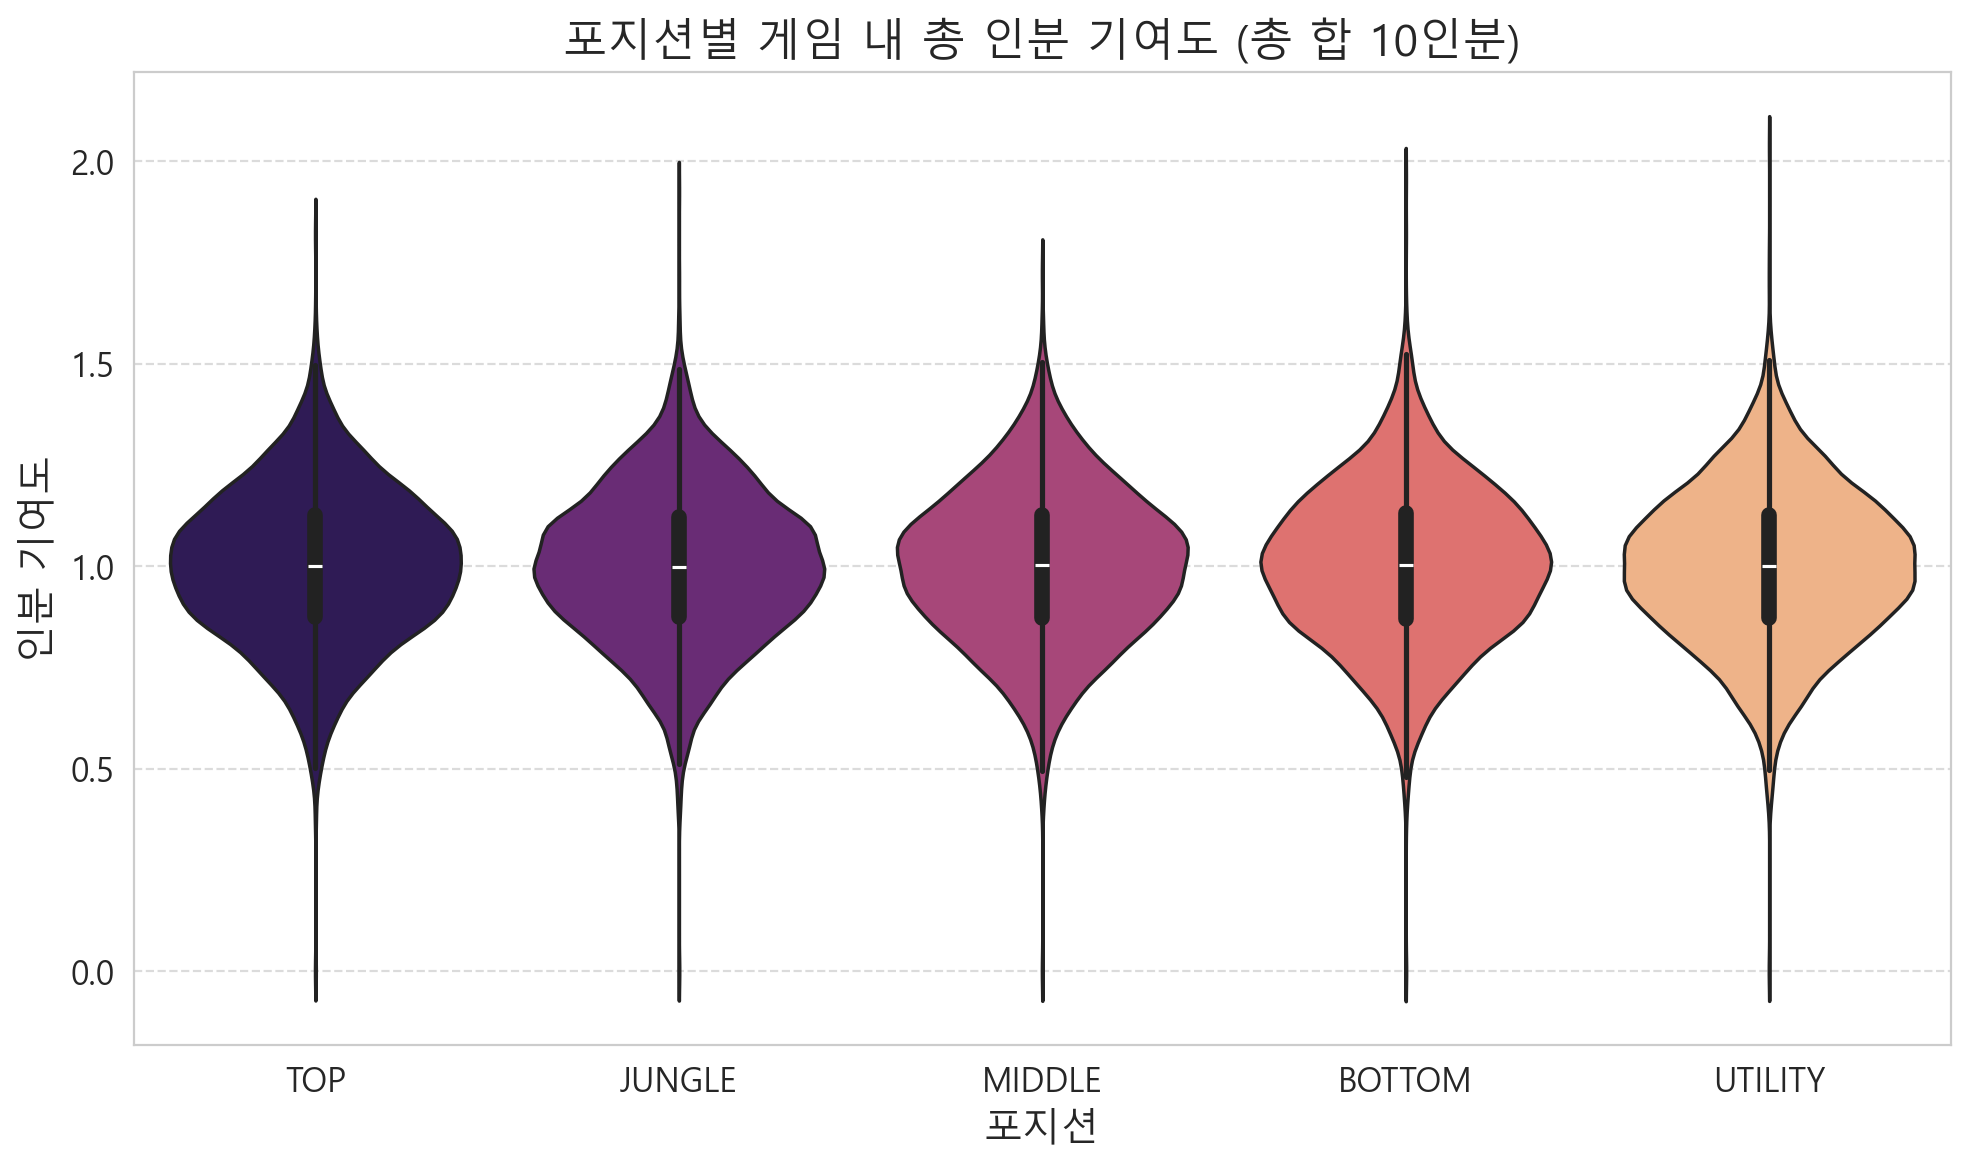

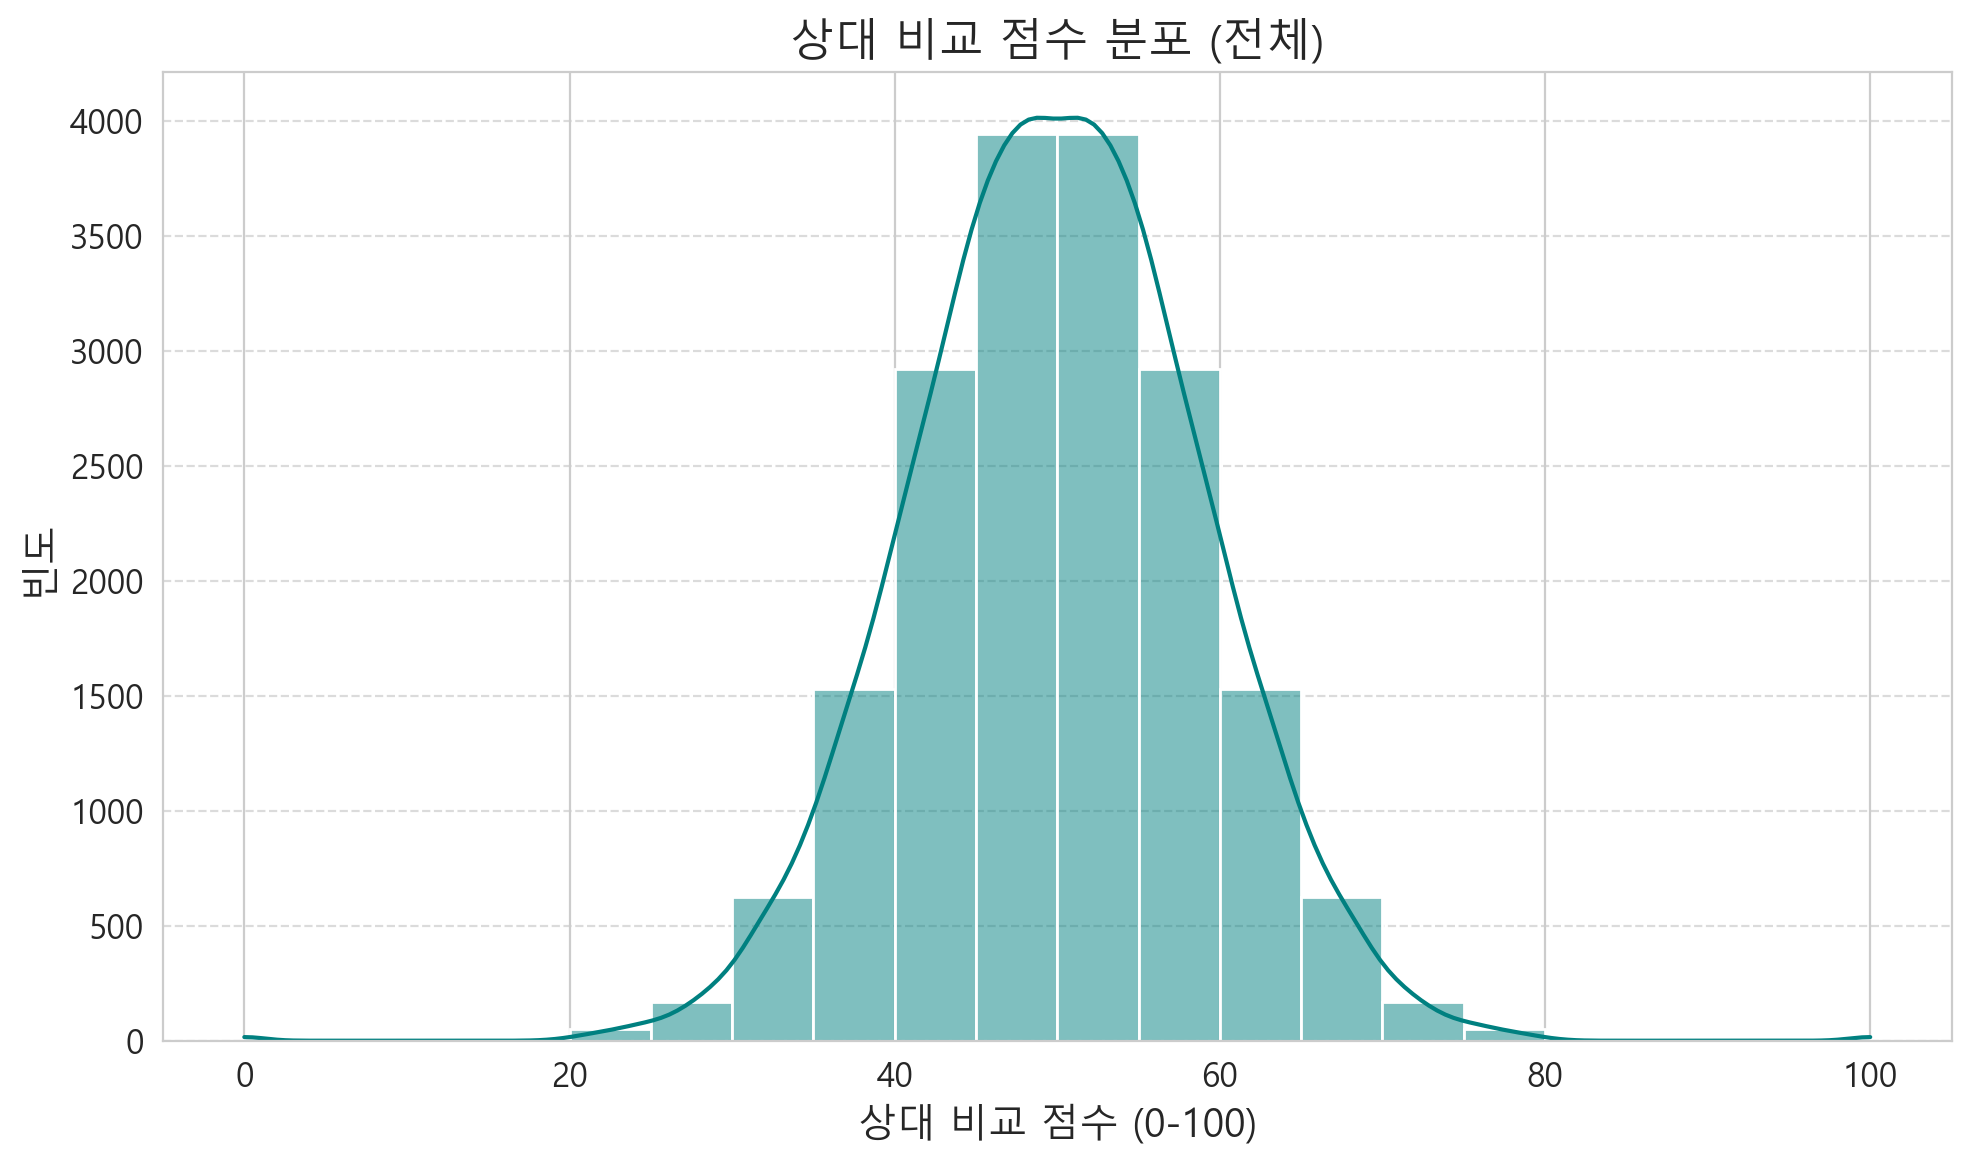

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18020\3251770155.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


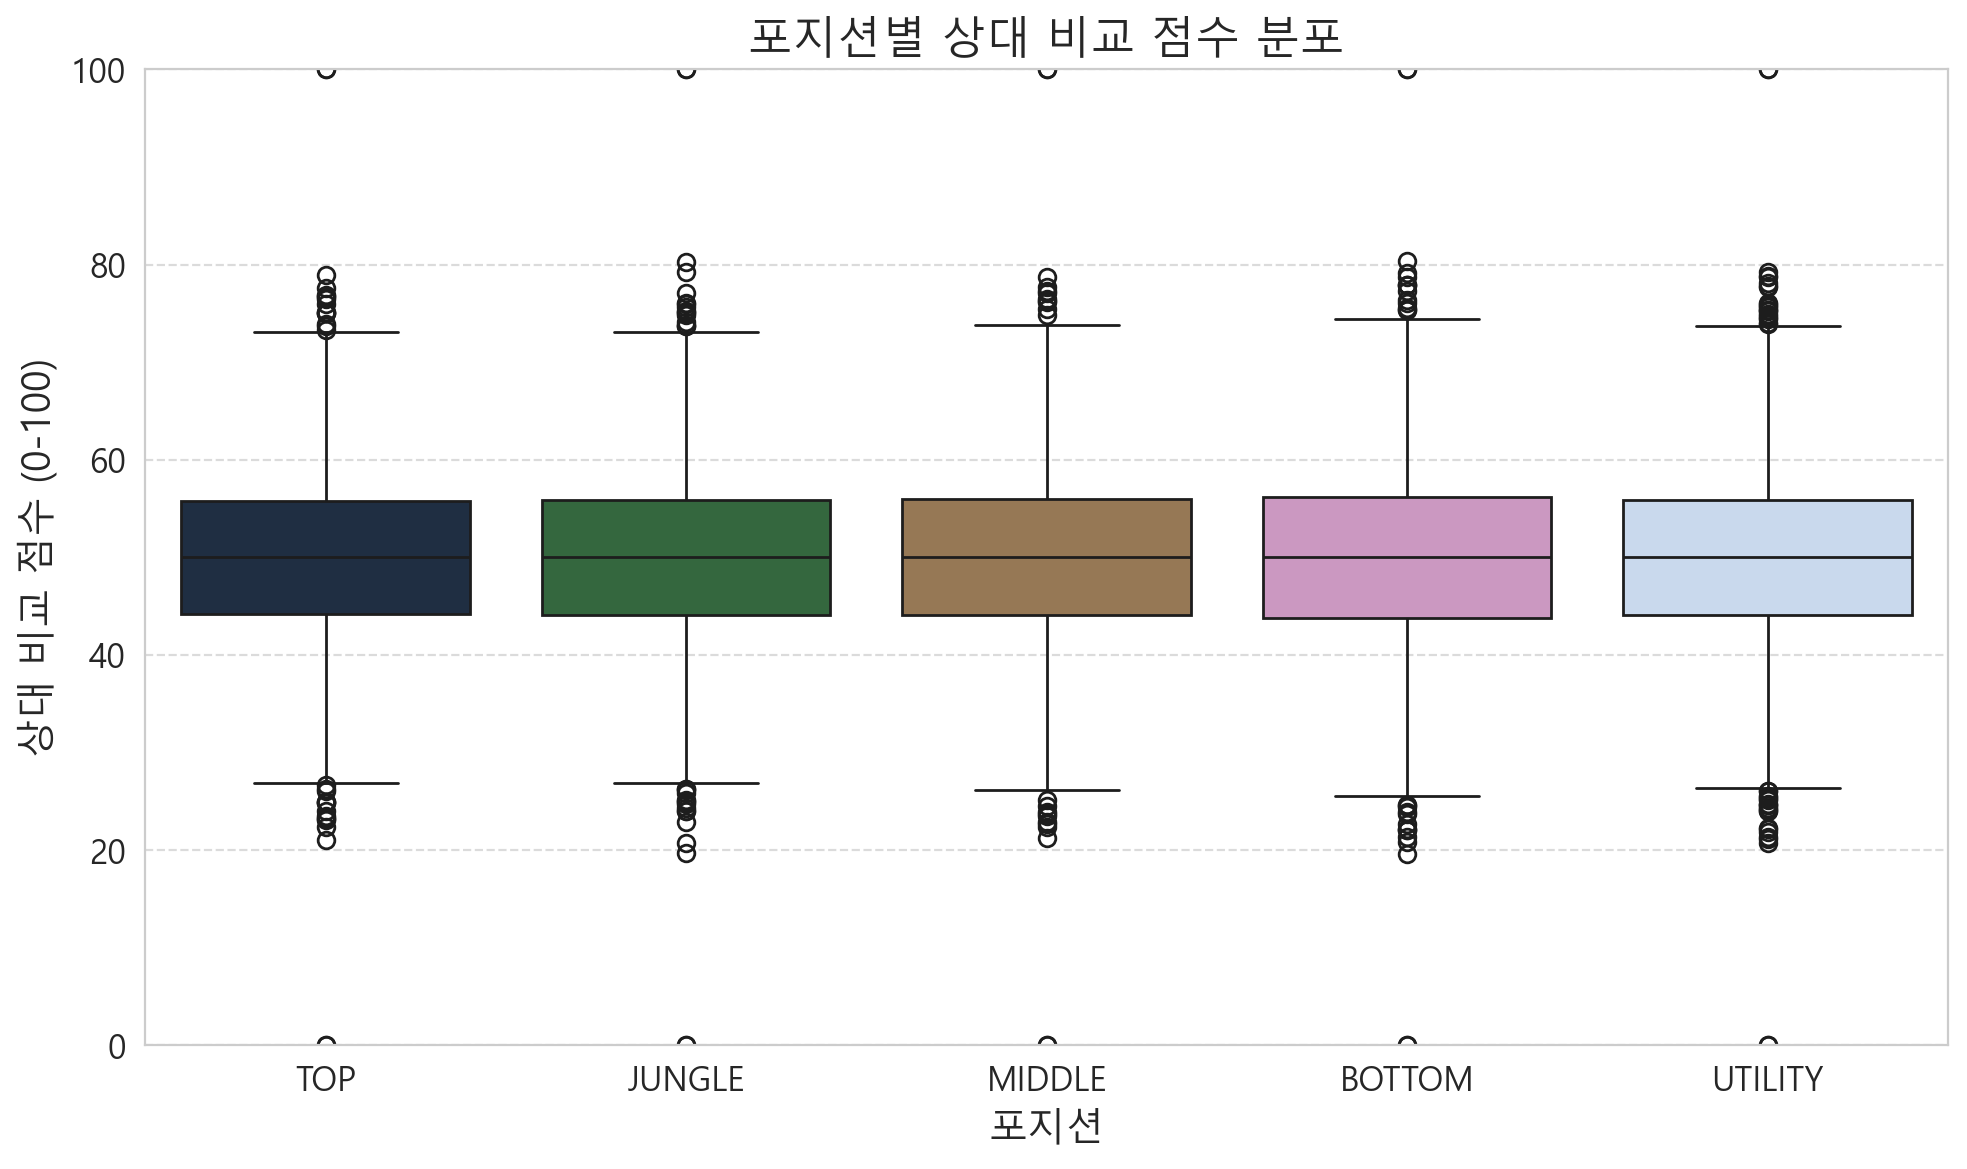

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer
import matplotlib.pyplot as plt
import seaborn as sns

# 폰트 설정 (시각화 시 한글 깨짐 방지)
plt.rcParams.update({'font.size': 12, 'font.family': 'Malgun Gothic'})
# For macOS/Linux users, uncomment one of these:
# plt.rcParams['font.family'] = 'AppleGothic'
# plt.rcParams['font.family'] = 'NanumGothic'

# ----------------------------------------------------
# 1. '몇 인분' 컬럼 추가 (게임 전체 기여도 - 총 합이 10인분)
# ----------------------------------------------------
print("\n✨ 1. '몇 인분' 컬럼 (게임 전체 기여도, 총 합 10인분) 계산 중...")

# 각 replay_code별 game_impact_winloss_norm 합계 계산
game_wide_impact_sum = mmr_df_cleaned_default.groupby('replay_code')['game_impact_winloss_norm'].transform('sum')

# 한 게임당 총 플레이어 수
players_per_game = 10

mmr_df_cleaned_default['game_n_person_contribution'] = (
    mmr_df_cleaned_default['game_impact_winloss_norm'] / game_wide_impact_sum * players_per_game
).fillna(0)

print("\n--- '몇 인분' 컬럼 샘플 (game_n_person_contribution) ---")
print(
    mmr_df_cleaned_default[
        ['replay_code', 'puuid', 'position', 'game_impact_winloss_norm', 'game_n_person_contribution']
    ]
    .head(20)
    .sort_values(by='replay_code')
)

# 검증용
# print("\n--- 검증: 게임별 '몇 인분'의 총합 ---")
# print(mmr_df_cleaned_default.groupby('replay_code')['game_n_person_contribution'].sum().head())

# ----------------------------------------------------
# 2. 상대와 비교 점수 컬럼 추가 (game_impact_vs_opponent)
# ----------------------------------------------------
print("\n✨ 2. 상대와 비교 점수 컬럼 계산 중...")

df_comp = mmr_df_cleaned_default[
    ['replay_code', 'position', 'game_result', 'game_impact_winloss_norm', 'puuid']
].copy()

merged_df = pd.merge(
    df_comp[df_comp['game_result'] == 1],  # 승리 팀 플레이어
    df_comp[df_comp['game_result'] == 0],  # 패배 팀 플레이어
    on=['replay_code', 'position'],
    suffixes=('_winner', '_loser'),
    how='inner'
)

merged_df['total_impact'] = (
    merged_df['game_impact_winloss_norm_winner'] +
    merged_df['game_impact_winloss_norm_loser']
)

merged_df['game_impact_vs_opponent_winner'] = (
    merged_df['game_impact_winloss_norm_winner'] / merged_df['total_impact'] * 100
).fillna(0)

merged_df['game_impact_vs_opponent_loser'] = (
    merged_df['game_impact_winloss_norm_loser'] / merged_df['total_impact'] * 100
).fillna(0)

result_list = []

for _, row in merged_df.iterrows():
    result_list.append({
        'replay_code': row['replay_code'],
        'position': row['position'],
        'puuid': row['puuid_winner'],
        'game_impact_vs_opponent': row['game_impact_vs_opponent_winner']
    })
    result_list.append({
        'replay_code': row['replay_code'],
        'position': row['position'],
        'puuid': row['puuid_loser'],
        'game_impact_vs_opponent': row['game_impact_vs_opponent_loser']
    })

game_impact_vs_opponent_df = pd.DataFrame(result_list)

mmr_df_cleaned_default = pd.merge(
    mmr_df_cleaned_default,
    game_impact_vs_opponent_df,
    on=['replay_code', 'puuid', 'position'],
    how='left'
)

mmr_df_cleaned_default['game_impact_vs_opponent'] = (
    mmr_df_cleaned_default['game_impact_vs_opponent'].fillna(np.nan)
)

print("\n--- 상대와 비교 점수 컬럼 샘플 (game_impact_vs_opponent) ---")
print(
    mmr_df_cleaned_default[
        ['replay_code', 'puuid', 'position', 'game_result',
         'game_impact_winloss_norm', 'game_impact_vs_opponent']
    ].head(10)
)

# ----------------------------------------------------
# 3. 시각화 및 최종 확인
# ----------------------------------------------------
print("\n--- 최종 확인 ---")
print(
    mmr_df_cleaned_default[
        ['replay_code', 'puuid', 'position', 'game_result',
         'game_impact_winloss_norm', 'game_n_person_contribution', 'game_impact_vs_opponent']
    ].head(20)
)

# '몇 인분' 컬럼 분포 시각화 (포지션별)
plt.figure(figsize=(10, 6))
sns.violinplot(
    x='position',
    y='game_n_person_contribution',
    data=mmr_df_cleaned_default,
    palette='magma'
)
plt.title('포지션별 게임 내 총 인분 기여도 (총 합 10인분)', fontsize=16)
plt.xlabel('포지션', fontsize=14)
plt.ylabel('인분 기여도', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# '상대 비교 점수' 컬럼 분포 시각화 (전체)
plt.figure(figsize=(10, 6))
sns.histplot(
    mmr_df_cleaned_default['game_impact_vs_opponent'].dropna(),
    kde=True,
    bins=20,
    color='teal'
)
plt.title('상대 비교 점수 분포 (전체)', fontsize=16)
plt.xlabel('상대 비교 점수 (0-100)', fontsize=14)
plt.ylabel('빈도', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 포지션별 상대 비교 점수 분포 (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='position',
    y='game_impact_vs_opponent',
    data=mmr_df_cleaned_default,
    palette='cubehelix'
)
plt.title('포지션별 상대 비교 점수 분포', fontsize=16)
plt.xlabel('포지션', fontsize=14)
plt.ylabel('상대 비교 점수 (0-100)', fontsize=14)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
mmr_df_cleaned_default[[
    'replay_code',
    'puuid',
    'position',
    'game_result',
    'game_impact_winloss_norm',
    'game_n_person_contribution',
    'game_impact_vs_opponent'
]].head(20)

,replay_code,puuid,position,game_result,game_impact_winloss_norm,game_n_person_contribution,game_impact_vs_opponent
0,RPY-260108-1t_0108_2009-2,f9ddea1d-7bd9-54a6-98aa-0c122b2bbbab,TOP,0,52.551187,1.036965,50.302183
1,RPY-260108-1t_0108_2009-2,bae2876d-9787-57cd-a7ed-531726041d87,JUNGLE,0,34.383521,0.678472,36.898538
2,RPY-260108-1t_0108_2009-2,5b13638b-769a-50d8-9b25-68a606cbbb5d,MIDDLE,0,32.060734,0.632638,34.859679
3,RPY-260108-1t_0108_2009-2,24efaca6-cfb8-5860-b673-cc5c44d952ca,BOTTOM,0,47.152210,0.930430,43.701092
4,RPY-260108-1t_0108_2009-2,c1c13c35-aa88-5cb2-a28e-43bcf44124df,UTILITY,0,41.381789,0.816565,37.876095
5,RPY-260108-1t_0108_2009-2,f5a173bf-10b4-52bc-9a5d-002808b72f5e,TOP,1,51.919800,1.024507,49.697817
6,RPY-260108-1t_0108_2009-2,d96e2c4b-96c3-5089-b786-05b994f847af,JUNGLE,1,58.800445,1.160279,63.101462
7,RPY-260108-1t_0108_2009-2,60c6f4f8-34f5-5ffd-b2a4-a2e33730d642,MIDDLE,1,59.910089,1.182175,65.140321
8,RPY-260108-1t_0108_2009-2,e7ba9d3d-8d5f-5d45-8b5e-943fc25c6b76,BOTTOM,1,60.744887,1.198648,56.298908
9,RPY-260108-1t_0108_2009-2,241fe26c-57e7-5481-9f4e-ad52521eb3bc,UTILITY,1,67.873900,1.339321,62.123905


# MMR 산정 로직 설계 (ELO 기반 + 퍼포먼스 보정)

기존 MMR 시스템은 단순 승패 기반으로 점수를 갱신하기 때문에,  
개인의 실제 퍼포먼스를 충분히 반영하지 못하는 한계가 있다.

이를 해결하기 위해 본 프로젝트에서는  
ELO 기반 평가 구조에 개인 기여도와 상대 비교 지표를 결합한  
MMR_custom 업데이트 로직을 설계하였다.

## 1. 기본 구조: ELO 기반 기대 성과 반영

플레이어의 MMR 변화는 다음과 같은 ELO 기반 기대 성과를 바탕으로 계산된다.

- 기대 성과(Expected Score):  
  두 플레이어의 MMR 차이를 기반으로 승리 확률 계산

- 실제 성과(Actual Score):  
  `game_impact_vs_opponent`를 활용하여 단순 승패가 아닌 실제 퍼포먼스 반영

이를 통해 단순히 승리했는지가 아니라  
“얼마나 잘 이겼는지 / 얼마나 잘 졌는지”를 반영할 수 있도록 설계하였다.


## 2. 개인 퍼포먼스 보정 (Personal Factor)

MMR 변화량에는 다음 두 지표가 반영된다:

- `game_n_person_contribution` → 팀 내 기여도
- `game_impact_vs_opponent` → 상대 포지션 대비 경쟁력

각 지표를 전체 평균 대비 정규화하고,
극단값을 방지하기 위해 0.5 ~ 2 범위로 clipping을 적용하였다.

최종적으로 다음과 같이 결합된다: ```personal_factor = (기여도^α) × (상대비교^β)```

이를 통해 단순 승패가 아닌  
**개인의 실제 영향력 기반 보정**이 가능해졌다.


## 3. 기대 대비 성과 반영 (Relative Factor)

ELO 기대 성과 대비 실제 성과를 비교하여  
성과 대비 효율을 반영하였다.

```relative_factor = actual / expected```

```final_factor = personal_factor × (relative_factor^γ)```

이를 통해:
- 강한 상대를 이겼을 경우 추가 보상
- 약한 상대에게 고전할 경우 페널티

가 자연스럽게 반영되도록 설계하였다.

## 4. K-Factor 동적 조정

MMR이 높아질수록 점수 변동폭이 줄어들도록  
K-Factor 감소 구조를 적용하였다.

- 일정 MMR 이상에서 점진적으로 감소
- 최소 변동폭을 보장하여 수렴 방지

이를 통해:
- 상위 구간에서 점수 안정성 확보
- 비정상적인 급등/급락 방지


## 5. 최종 MMR 변화량 계산

최종 변화량은 다음 요소를 모두 반영하여 계산된다:

- 기본 승/패 점수 (BASE_WIN / BASE_LOSS)
- 개인 퍼포먼스 보정 (personal_factor)
- 기대 대비 성과 (relative_factor)
- K-Factor

또한 과도한 변동을 방지하기 위해:
- 최소/최대 변화량 제한 (clipping)
- 승/패 최소 보정값 설정

을 적용하였다.

## 6. Total MMR 산정 방식

플레이어의 전체 MMR은  
포지션별 MMR을 단순 평균이 아닌  
“플레이한 게임 수 기반 가중 평균”으로 계산하였다.

이를 통해:
- 특정 포지션만 플레이한 경우 왜곡 방지
- 실제 플레이 비중을 반영한 MMR 산출

=== ELO 포함 summary_df ===
                                  puuid  total_mmr  total_games  \
0  671404fd-fc00-5c13-aa30-92b31d4e7e37       2100          388   
1  15fe9805-b415-54bf-ae49-6af14bf5361d       1844          195   
2  7fa5473a-9405-5362-8984-2e011b6e7874       1792          202   
3  60c6f4f8-34f5-5ffd-b2a4-a2e33730d642       1753          249   
4  b2809939-b0a0-5784-804e-1c64079d3832       1742          352   

   overall_winrate  TOP_mmr  TOP_winrate  TOP_games  BOTTOM_mmr  \
0            57.47   1287.0         0.00        1.0      1431.0   
1            61.03   1397.0        56.25       16.0      1237.0   
2            56.44   1272.0        33.33        6.0      1326.0   
3            54.22   1260.0         0.00        3.0      1975.0   
4            52.27   1292.0        43.18       44.0      1952.0   

   BOTTOM_winrate  BOTTOM_games  MIDDLE_mmr  MIDDLE_winrate  MIDDLE_games  \
0           62.50          24.0      1319.0           47.62          21.0   
1           22

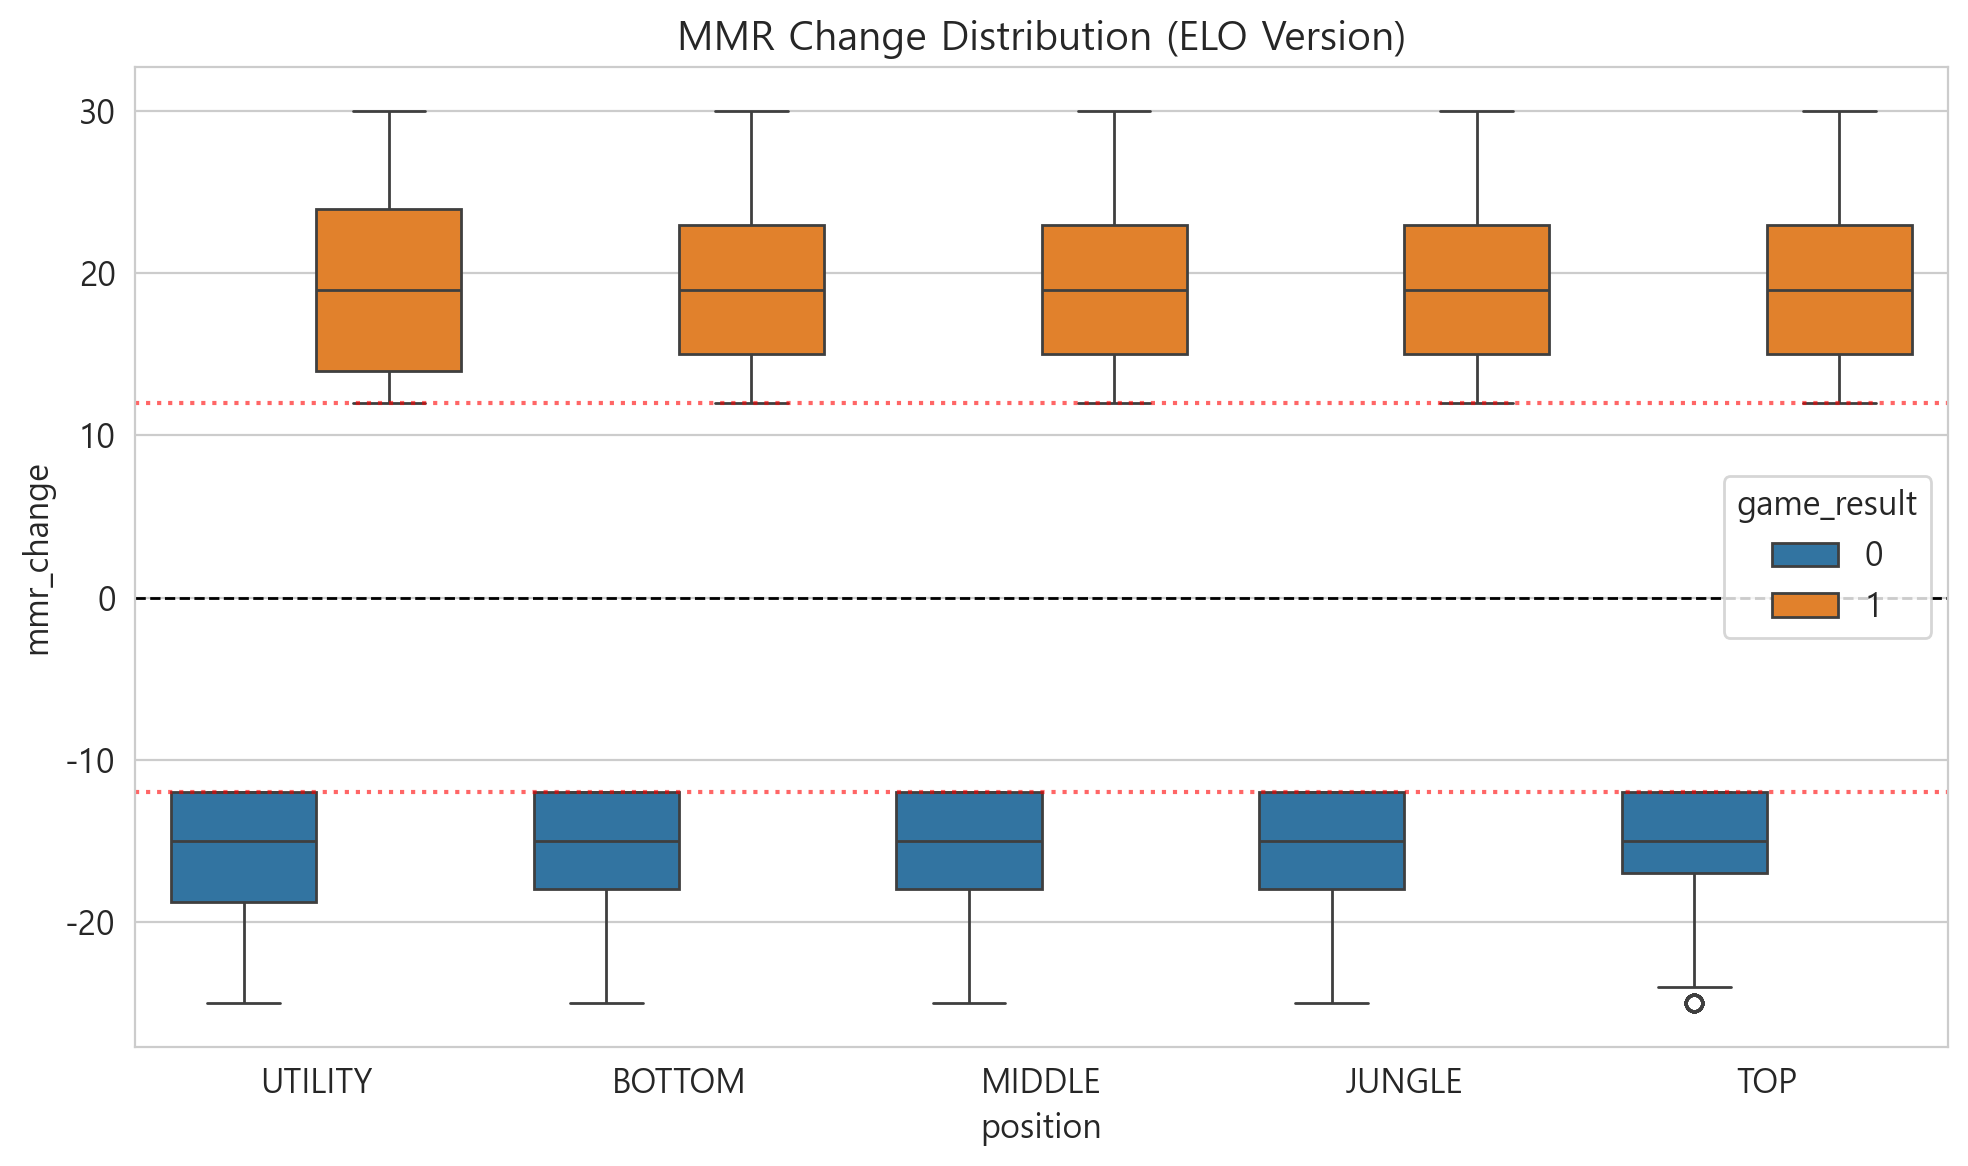

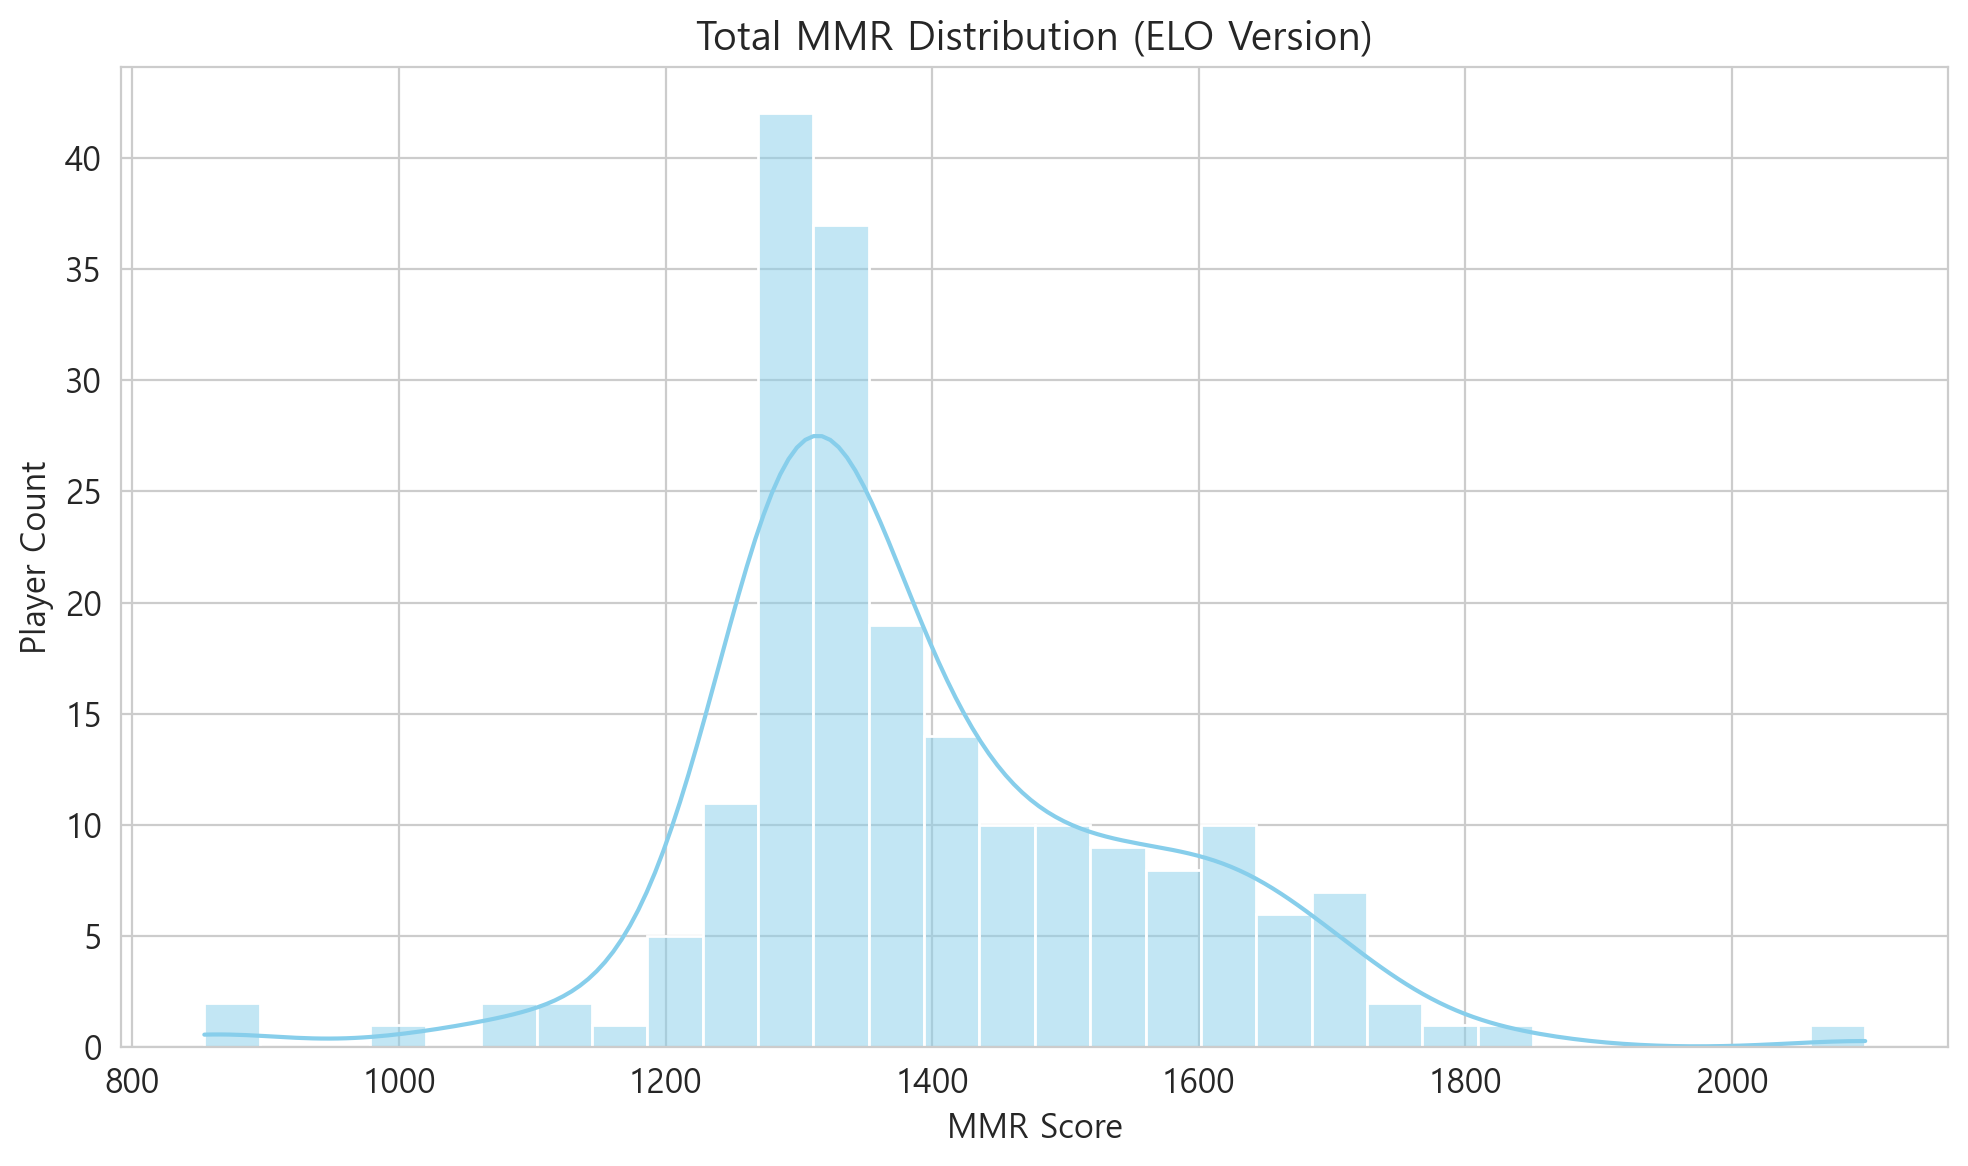

In [16]:
# ==============================================================
# [1] IMPORT
# ==============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ==============================================================
# [2] PARAMETER
# ==============================================================
BASE_WIN = 20
BASE_LOSS = -15

ALPHA = 0.6   # 개인 기여도 반영
BETA = 0.4    # 상대 포지션 비교 지표 반영
GAMMA = 0.2   # ELO 기대성과 대비 실제성과 반영

INITIAL_MMR = 1300
MMR_MIN_CHANGE = -25
MMR_MAX_CHANGE = 30

MMR_K_DECAY_START = 1500
MMR_K_DECAY_RATE = 0.002
MMR_K_MIN = 0.35


# ==============================================================
# [3] FUNCTION
# ==============================================================

def expected_performance(mmr_a, mmr_b):
    """
    ELO 기대성과 계산
    """
    return 1 / (1 + 10 ** ((mmr_b - mmr_a) / 400))


def calculate_personal_factor(row, f1_mean, f2_mean):
    """
    개인 기여도 factor
    - game_n_person_contribution
    - game_impact_vs_opponent
    """
    f1 = row['game_n_person_contribution'] / f1_mean if f1_mean != 0 else 1

    if pd.isna(row['game_impact_vs_opponent']) or f2_mean == 0:
        f2 = 1
    else:
        f2 = row['game_impact_vs_opponent'] / f2_mean

    f1 = np.clip(f1, 0.5, 2)
    f2 = np.clip(f2, 0.5, 2)

    return (f1 ** ALPHA) * (f2 ** BETA)


def calculate_k_factor(mmr):
    """
    MMR이 높아질수록 점수 변동폭 축소
    """
    k = 1.0
    if mmr > MMR_K_DECAY_START:
        k = 1.0 - ((mmr - MMR_K_DECAY_START) * MMR_K_DECAY_RATE)
    return max(k, MMR_K_MIN)


def make_summary_df_wide(mmr_df_updated):
    """
    summary_df를 wide 형식으로 생성
    예:
    puuid / total_mmr / total_games / overall_winrate /
    TOP_mmr / TOP_winrate / TOP_games / ...
    """
    positions = ['TOP', 'BOTTOM', 'MIDDLE', 'JUNGLE', 'UTILITY']

    # 1. 플레이어-포지션별 마지막 MMR
    pos_last = (
        mmr_df_updated
        .sort_values(by=['played_at', 'replay_code'])
        .groupby(['puuid', 'position'], as_index=False)
        .tail(1)
        [['puuid', 'position', 'pos_cumulative_mmr']]
        .rename(columns={'pos_cumulative_mmr': 'pos_mmr'})
    )

    # 2. 플레이어-포지션별 게임수 / 승수
    pos_stats = (
        mmr_df_updated
        .groupby(['puuid', 'position'], as_index=False)
        .agg(
            pos_games=('game_result', 'count'),
            pos_wins=('game_result', 'sum')
        )
    )
    pos_stats['pos_winrate'] = (pos_stats['pos_wins'] / pos_stats['pos_games'] * 100).round(2)

    # 3. merge
    pos_summary = pos_last.merge(pos_stats, on=['puuid', 'position'], how='outer')

    # 4. pivot
    mmr_wide = pos_summary.pivot(index='puuid', columns='position', values='pos_mmr')
    winrate_wide = pos_summary.pivot(index='puuid', columns='position', values='pos_winrate')
    games_wide = pos_summary.pivot(index='puuid', columns='position', values='pos_games')

    mmr_wide.columns = [f'{col}_mmr' for col in mmr_wide.columns]
    winrate_wide.columns = [f'{col}_winrate' for col in winrate_wide.columns]
    games_wide.columns = [f'{col}_games' for col in games_wide.columns]

    # 5. 전체 게임 수 / 전체 승률
    overall_summary = (
        mmr_df_updated
        .groupby('puuid', as_index=False)
        .agg(
            total_games=('game_result', 'count'),
            total_wins=('game_result', 'sum')
        )
    )
    overall_summary['overall_winrate'] = (
        overall_summary['total_wins'] / overall_summary['total_games'] * 100
    ).round(2)

    # 6. total_mmr = 마지막 경기 기준 total_mmr
    total_mmr_df = (
        mmr_df_updated
        .sort_values(by=['played_at', 'replay_code'])
        .groupby('puuid', as_index=False)
        .tail(1)
        [['puuid', 'total_mmr']]
    )

    overall_summary = overall_summary.merge(total_mmr_df, on='puuid', how='left')
    overall_summary = overall_summary.drop(columns='total_wins')

    # 7. 전체 merge
    summary_df = (
        overall_summary
        .merge(mmr_wide, on='puuid', how='left')
        .merge(winrate_wide, on='puuid', how='left')
        .merge(games_wide, on='puuid', how='left')
    )

    # 8. 포지션 컬럼 보정
    for pos in positions:
        if f'{pos}_mmr' not in summary_df.columns:
            summary_df[f'{pos}_mmr'] = np.nan
        if f'{pos}_winrate' not in summary_df.columns:
            summary_df[f'{pos}_winrate'] = np.nan
        if f'{pos}_games' not in summary_df.columns:
            summary_df[f'{pos}_games'] = 0

    # 9. 컬럼 순서
    ordered_cols = [
        'puuid', 'total_mmr', 'total_games', 'overall_winrate',
        'TOP_mmr', 'TOP_winrate', 'TOP_games',
        'BOTTOM_mmr', 'BOTTOM_winrate', 'BOTTOM_games',
        'MIDDLE_mmr', 'MIDDLE_winrate', 'MIDDLE_games',
        'JUNGLE_mmr', 'JUNGLE_winrate', 'JUNGLE_games',
        'UTILITY_mmr', 'UTILITY_winrate', 'UTILITY_games'
    ]

    summary_df = summary_df[ordered_cols].sort_values(by='total_mmr', ascending=False).reset_index(drop=True)

    return summary_df


# ==============================================================
# [4] ELO 포함 MMR 업데이트
# ==============================================================

def update_mmr_elo(df):
    df = df.sort_values(by=['played_at', 'replay_code', 'puuid']).copy()

    player_pos_mmr = {}
    player_pos_record = {}
    updated_rows = []

    f1_mean = df['game_n_person_contribution'].mean()
    f2_mean = df['game_impact_vs_opponent'].mean()

    for replay_code, game_df in df.groupby('replay_code', sort=False):
        pre_mmr = {}
        game_updates = []

        # 경기 시작 전 MMR snapshot
        for _, row in game_df.iterrows():
            pid = row['puuid']
            pos = row['position']

            player_pos_mmr.setdefault(pid, {})
            player_pos_record.setdefault(pid, {})

            player_pos_mmr[pid].setdefault(pos, INITIAL_MMR)
            player_pos_record[pid].setdefault(pos, {'win': 0, 'total': 0})

            pre_mmr[(pid, pos)] = int(player_pos_mmr[pid][pos])

        # 각 플레이어 변화량 계산
        for _, row in game_df.iterrows():
            pid = row['puuid']
            pos = row['position']
            current_mmr = pre_mmr[(pid, pos)]

            # 같은 포지션 상대 찾기
            opponent_df = game_df[
                (game_df['position'] == pos) &
                (game_df['puuid'] != pid)
            ]

            opponent_mmr = INITIAL_MMR
            if not opponent_df.empty:
                opp_id = opponent_df.iloc[0]['puuid']
                opponent_mmr = pre_mmr.get((opp_id, pos), INITIAL_MMR)

            expected = expected_performance(current_mmr, opponent_mmr)

            actual = (
                row['game_impact_vs_opponent'] / 100
                if not pd.isna(row['game_impact_vs_opponent'])
                else expected
            )

            relative_factor = actual / expected if expected > 0 else 1
            personal_factor = calculate_personal_factor(row, f1_mean, f2_mean)
            final_factor = personal_factor * (relative_factor ** GAMMA)

            k = calculate_k_factor(current_mmr)

            if row['game_result'] == 1:
                delta = BASE_WIN * final_factor
                delta = delta * k
                delta = np.clip(max(delta, 12), 12, MMR_MAX_CHANGE)
            else:
                delta = BASE_LOSS * final_factor
                delta = delta * k
                delta = np.clip(min(delta, -12), MMR_MIN_CHANGE, -12)

            delta = int(round(delta))
            new_mmr = int(current_mmr + delta)

            row_copy = row.copy()
            row_copy['pre_game_pos_mmr'] = int(current_mmr)
            row_copy['expected_score'] = round(expected, 4)
            row_copy['actual_score'] = round(actual, 4)
            row_copy['relative_factor'] = round(relative_factor, 4)
            row_copy['personal_factor'] = round(personal_factor, 4)
            row_copy['final_factor'] = round(final_factor, 4)
            row_copy['mmr_change'] = int(delta)
            row_copy['pos_cumulative_mmr'] = int(new_mmr)

            game_updates.append((pid, pos, row['game_result'], new_mmr, row_copy))

        # 경기 결과 반영
        for pid, pos, result, new_mmr, row_copy in game_updates:
            player_pos_mmr[pid][pos] = new_mmr
            player_pos_record[pid][pos]['total'] += 1

            if result == 1:
                player_pos_record[pid][pos]['win'] += 1

            # total_mmr = 포지션별 경기수 가중 평균
            pos_mmr = player_pos_mmr[pid]
            pos_record = player_pos_record[pid]

            weighted_sum = 0
            total_games = 0

            for p in pos_mmr:
                g = pos_record[p]['total']
                weighted_sum += pos_mmr[p] * g
                total_games += g

            total_mmr = int(round(weighted_sum / total_games)) if total_games > 0 else INITIAL_MMR

            row_copy['total_mmr'] = total_mmr
            updated_rows.append(row_copy)

    mmr_df_updated = pd.DataFrame(updated_rows)
    summary_df = make_summary_df_wide(mmr_df_updated)

    return mmr_df_updated, summary_df


# ==============================================================
# [5] 실행
# ==============================================================

mmr_df_updated_elo, summary_df_elo = update_mmr_elo(mmr_df_cleaned_default.copy())

print("=== ELO 포함 summary_df ===")
print(summary_df_elo.head())


# ==============================================================
# [6] 시각화
# ==============================================================

plt.figure(figsize=(10, 6))
sns.boxplot(data=mmr_df_updated_elo, x='position', y='mmr_change', hue='game_result')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axhline(12, color='red', linestyle=':', alpha=0.6)
plt.axhline(-12, color='red', linestyle=':', alpha=0.6)
plt.title("MMR Change Distribution (ELO Version)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(summary_df_elo['total_mmr'], kde=True, bins=30, color='skyblue')
plt.title("Total MMR Distribution (ELO Version)")
plt.xlabel("MMR Score")
plt.ylabel("Player Count")
plt.tight_layout()
plt.show()

# 📊 사용자 요약 테이블 생성 및 결과 구조화

MMR 계산 결과를 실제 서비스 및 분석에 활용하기 위해, 플레이어 단위 및 포지션 단위의 요약 테이블을 생성하였다.


## 1. 유저 정보 결합

MMR 결과에 유저 식별을 위한 `riot_name`을 추가하여  
분석 결과의 가독성과 활용성을 높였다.


## 2. 포지션별 / 전체 MMR 정리

각 플레이어에 대해:

- 포지션별 MMR
- 포지션별 승률 및 게임 수
- 전체 MMR (포지션별 게임 수 가중 평균)

을 통합하여 summary 형태로 구성하였다.

특히 전체 MMR은 단순 평균이 아닌  
**플레이 비중(게임 수)을 반영한 가중 평균 방식**으로 계산하였다.

## 3. 핵심 지표 우선 배치

분석의 핵심이 되는 지표를 상단에 배치하였다:

- `game_impact_winloss_norm`
- `game_n_person_contribution`
- `game_impact_vs_opponent`

이를 통해 사용자가 MMR뿐 아니라  
퍼포먼스 지표를 함께 해석할 수 있도록 구성하였다.


## 4. 포지션별 / 전체 데이터 분리

결과 테이블은 다음과 같이 구성하였다:

- 포지션별 시트 (TOP, JUNGLE, MIDDLE, BOTTOM, UTILITY)
- 전체 통합 시트 (TOTAL)

각 시트는:
- MMR 기준 내림차순 정렬
- 평균 행 추가 (AVERAGE)
- 주요 지표 포함

형태로 구성되어 직관적인 비교가 가능하도록 설계하였다.

## 5. 결과 활용 구조

최종적으로 생성된 테이블은:

- 유저 랭킹 시스템
- 포지션별 퍼포먼스 비교
- 서비스 UI (전적 페이지)
- 데이터 기반 분석 리포트

에 직접 활용될 수 있도록 설계되었다.

In [ ]:
import pandas as pd
import numpy as np

# ==================================================
# 1. 유저 이름 파일 로드
# ==================================================
user_name_path = r"C:/Users/PC/Desktop/김필준/data/2026 유저_0415.csv"

try:
    user_name = pd.read_csv(user_name_path, encoding='utf-8', on_bad_lines='skip')
    print("UTF-8 인코딩으로 데이터 로드에 성공했습니다.")
except UnicodeDecodeError:
    user_name = pd.read_csv(user_name_path, encoding='cp949', on_bad_lines='skip')
    print("CP949 인코딩으로 데이터 로드에 성공했습니다.")

user_name = user_name[['puuid', 'riot_name']].drop_duplicates()

# ==================================================
# 2. summary_df_elo에 riot_name 붙이기
# ==================================================
cols_to_drop = ['riot_name', 'riot_name_x', 'riot_name_y']
summary_df_elo = summary_df_elo.drop(
    columns=[c for c in cols_to_drop if c in summary_df_elo.columns]
)

summary_df_elo = summary_df_elo.merge(
    user_name,
    on='puuid',
    how='left'
)

cols = ['riot_name'] + [c for c in summary_df_elo.columns if c != 'riot_name']
summary_df_elo = summary_df_elo[cols]

# ==================================================
# 3. total_mmr 보정
# ==================================================
position_mmr_cols = ['TOP_mmr', 'JUNGLE_mmr', 'MIDDLE_mmr', 'BOTTOM_mmr', 'UTILITY_mmr']
existing_position_mmr_cols = [c for c in position_mmr_cols if c in summary_df_elo.columns]

if 'total_mmr' not in summary_df_elo.columns:
    if len(existing_position_mmr_cols) > 0:
        summary_df_elo['total_mmr'] = summary_df_elo[existing_position_mmr_cols].mean(axis=1)
        print("total_mmr 컬럼이 없어 포지션별 mmr 평균으로 생성했습니다.")
    else:
        summary_df_elo['total_mmr'] = np.nan
        print("포지션별 mmr 컬럼이 없어 total_mmr를 NaN으로 생성했습니다.")

# ==================================================
# 4. 경기 데이터 복사
#    (이미 per-minute 처리 끝난 상태라고 가정)
# ==================================================
df = mmr_df_updated_elo.copy()

# ==================================================
# 5. 사용할 지표 컬럼 정의
#    game impact 3개를 우선 배치할 수 있게 분리
# ==================================================
priority_metric_cols = [
    'game_impact_winloss_norm',
    'game_n_person_contribution',
    'game_impact_vs_opponent'
]

other_metric_candidates =  [
    'kills',
    'deaths',
    'assists',
    'gold_per_min',
    'exp_per_min',
    'dpm',
    'damage_to_turrets_per_min',
    'vision_score',
    'damage_taken_per_min',
    'cs_per_min',
    'kda',
    'damage_taken_per_death',
    'damage_dealt_per_death',
    'wards_placed_per_min',
    'wards_killed_per_min',
    'cc_time_per_min',
    'heal_on_teammates',
    'shield_on_teammates',
    'lane_gold_diff'
]

priority_metric_cols = [col for col in priority_metric_cols if col in df.columns]
other_metric_cols = [col for col in other_metric_candidates if col in df.columns]

existing_metric_cols = priority_metric_cols + other_metric_cols

print("사용 지표 컬럼:")
print(existing_metric_cols)

# ==================================================
# 6. 유저 + 포지션 기준 평균 지표 계산
# ==================================================
player_pos_metrics = (
    df.groupby(['puuid', 'position'], as_index=False)[existing_metric_cols]
      .mean()
)

# ==================================================
# 7. 유저 전체 기준 평균 지표 계산 (TOTAL용)
# ==================================================
player_total_metrics = (
    df.groupby('puuid', as_index=False)[existing_metric_cols]
      .mean()
)

# ==================================================
# 8. summary_df_elo를 long 형태로 변환
# ==================================================
positions = ['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'UTILITY']
summary_long_list = []

for pos in positions:
    mmr_col = f'{pos}_mmr'
    win_col = f'{pos}_winrate'
    game_col = f'{pos}_games'

    required_cols = ['riot_name', 'puuid', mmr_col, win_col, game_col]

    if all(col in summary_df_elo.columns for col in required_cols):
        temp = summary_df_elo[required_cols].copy()
        temp.columns = ['riot_name', 'puuid', 'MMR', 'win_rate', 'games']
        temp['position'] = pos
        summary_long_list.append(temp)
    else:
        print(f"{pos} 관련 컬럼이 summary_df_elo에 없어 제외됩니다.")

summary_long = pd.concat(summary_long_list, ignore_index=True)
summary_long = summary_long[summary_long['games'] > 0].copy()

# ==================================================
# 9. 포지션별 merge
# ==================================================
player_pos_final = summary_long.merge(
    player_pos_metrics,
    on=['puuid', 'position'],
    how='left'
)

# ==================================================
# 10. TOTAL용 summary 생성
# ==================================================
game_cols = [f'{pos}_games' for pos in positions if f'{pos}_games' in summary_df_elo.columns]

summary_total = summary_df_elo[['riot_name', 'puuid', 'total_mmr']].copy()

# 전체 판수
summary_total['games'] = summary_df_elo[game_cols].sum(axis=1)

# 전체 승률 계산 (판수 가중 평균)
weighted_wins = 0
for pos in positions:
    win_col = f'{pos}_winrate'
    game_col = f'{pos}_games'
    if win_col in summary_df_elo.columns and game_col in summary_df_elo.columns:
        weighted_wins += (summary_df_elo[win_col] / 100.0) * summary_df_elo[game_col]

summary_total['win_rate'] = np.where(
    summary_total['games'] > 0,
    (weighted_wins / summary_total['games']) * 100,
    np.nan
)

summary_total['MMR'] = summary_total['total_mmr']
summary_total = summary_total[summary_total['games'] > 0].copy()

# ==================================================
# 11. TOTAL용 merge
# ==================================================
player_total_final = summary_total.merge(
    player_total_metrics,
    on='puuid',
    how='left'
)

# ==================================================
# 12. 포지션별 DataFrame 생성
#     - total_mmr 제외
#     - MMR 내림차순
#     - 평균 행 맨 위 추가
# ==================================================
position_dfs = {}

for pos in positions:
    df_pos = player_pos_final[player_pos_final['position'] == pos].copy()
    df_pos = df_pos.drop(columns=['position'])

    # 유저 데이터 MMR 내림차순
    df_pos = df_pos.sort_values(by='MMR', ascending=False).reset_index(drop=True)

    # 평균 행 생성
    avg_row = df_pos.mean(numeric_only=True)
    avg_row['riot_name'] = f'{pos}_AVERAGE'
    avg_row['puuid'] = ''

    avg_df = pd.DataFrame([avg_row])

    # 평균 행 맨 위 추가
    df_pos = pd.concat([avg_df, df_pos], ignore_index=True)

    # total_mmr는 포지션 시트에서 제거
    if 'total_mmr' in df_pos.columns:
        df_pos = df_pos.drop(columns=['total_mmr'])

    # 컬럼 순서 정리
    front_cols = ['riot_name', 'puuid', 'MMR', 'win_rate', 'games']
    ordered_metric_cols = priority_metric_cols + [c for c in other_metric_cols if c in df_pos.columns]
    remaining_cols = [col for col in df_pos.columns if col not in front_cols + ordered_metric_cols]

    df_pos = df_pos[front_cols + ordered_metric_cols + remaining_cols]

    # 숫자형 반올림
    numeric_cols = df_pos.select_dtypes(include='number').columns
    df_pos[numeric_cols] = df_pos[numeric_cols].round(3)

    position_dfs[pos] = df_pos

# ==================================================
# 13. TOTAL DataFrame 생성
#     - total_mmr 포함
#     - total_mmr 내림차순
#     - 평균 행 맨 위 추가
# ==================================================
total_df = player_total_final.copy()

# total_mmr 기준 내림차순
total_df = total_df.sort_values(by='total_mmr', ascending=False).reset_index(drop=True)

# 평균 행 생성
total_avg_row = total_df.mean(numeric_only=True)
total_avg_row['riot_name'] = 'TOTAL_AVERAGE'
total_avg_row['puuid'] = ''

total_avg_df = pd.DataFrame([total_avg_row])

# 평균 행 맨 위 추가
total_df = pd.concat([total_avg_df, total_df], ignore_index=True)

# TOTAL 컬럼 순서 정리
front_cols_total = ['riot_name', 'puuid', 'total_mmr', 'MMR', 'win_rate', 'games']
ordered_metric_cols_total = priority_metric_cols + [c for c in other_metric_cols if c in total_df.columns]
remaining_cols_total = [col for col in total_df.columns if col not in front_cols_total + ordered_metric_cols_total]

total_df = total_df[front_cols_total + ordered_metric_cols_total + remaining_cols_total]

# 숫자형 반올림
numeric_cols = total_df.select_dtypes(include='number').columns
total_df[numeric_cols] = total_df[numeric_cols].round(3)

position_dfs['TOTAL'] = total_df

# ==================================================
# 14. 확인
# ==================================================
print("TOTAL 데이터 예시")
print(position_dfs['TOTAL'].head())

print("\nTOP 데이터 예시")
print(position_dfs['TOP'].head())

# ==================================================
# 15. 엑셀 저장
# ==================================================
sheet_order = ['TOTAL', 'TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'UTILITY']

with pd.ExcelWriter('position_user_summary_final.xlsx') as writer:
    for sheet_name in sheet_order:
        if sheet_name in position_dfs:
            position_dfs[sheet_name].to_excel(writer, sheet_name=sheet_name, index=False)

print("\n엑셀 저장 완료: position_user_summary_final.xlsx")

# 🧭 플레이 스타일 리포트 설계 목적

본 작업은 MMR 점수만으로는 유저의 플레이 성향을 충분히 설명하기 어렵다는 문제에서 출발하였다.
동일한 MMR을 가진 유저라도 어떤 유저는 교전 중심으로 게임을 풀고, 어떤 유저는 성장과 운영을 통해 영향력을 만든다.

따라서 본 리포트는 단순히 “점수가 높다/낮다”를 보여주는 것이 아니라, 유저가 어떤 방식으로 게임에 기여하는지를 해석하기 위해 설계하였다.

주요 목적은 다음과 같다.

| 목적         | 설명                                                 |
| ---------- | -------------------------------------------------- |
| 유저 성향 해석   | MMR, KDA, DPM 같은 단일 지표가 아니라 여러 지표 조합으로 플레이 스타일을 분류 |
| 포지션별 차이 반영 | 탑, 정글, 미드, 원딜, 서포터는 중요한 지표가 다르므로 포지션별 가중치 적용       |
| 비교 기준 제공   | 같은 MMR 밴드 또는 같은 포지션 유저와 비교하여 상대적 위치 확인             |
| 서비스 적용     | 전적 페이지, 유저 분석 페이지, 코칭 리포트에 활용 가능한 형태로 자동 출력        |


## ⚙️기본 설정

| 설정값                         | 의미                                              |
| --------------------------- | ----------------------------------------------- |
| `POS_LIST`                  | 분석 대상 포지션: TOP, JUNGLE, MIDDLE, BOTTOM, UTILITY |
| `bin_size=100`              | MMR 비교 구간을 100점 단위로 구분                          |
| `min_games_in_pos_group=20` | 비교군에 포함되기 위한 최소 포지션 판수                          |
| `radar_topk=8`              | 레이더 차트에 표시할 상위 핵심 지표 개수                         |
| `tendency_max_results=3`    | 포지션별 성향 분석 결과 최대 출력 개수                          |
| `min_band_users=5`          | 같은 MMR 밴드 내 비교 유저가 5명 미만이면 포지션 전체 기준으로 확장       |


## 📊 POS_RADAR_WEIGHTS 설정 기준

레이더 차트는 모든 지표를 동일하게 보는 것이 아니라, 포지션별로 중요한 지표에 더 높은 가중치를 부여한다.

예를 들어 원딜은 dpm, gold_per_min, damage_dealt_per_death가 중요하고, 서포터는 kda, game_n_person_contribution, game_impact_vs_opponent가 더 중요하다.

| 포지션     |  dpm | cs_per_min | gold_per_min | exp_per_min |  kda | damage_dealt_per_death | game_n_person_contribution | game_impact_vs_opponent |
| ------- | ---: | ---------: | -----------: | ----------: | ---: | ---------------------: | -------------------------: | ----------------------: |
| TOP     | 0.90 |       0.90 |         0.75 |        0.75 | 0.80 |                   0.85 |                       0.80 |                    1.00 |
| JUNGLE  | 0.80 |       0.75 |         0.75 |        0.75 | 0.90 |                   0.75 |                       0.90 |                    1.00 |
| MIDDLE  | 0.95 |       0.80 |         0.75 |        0.80 | 0.85 |                   0.80 |                       0.85 |                    1.00 |
| BOTTOM  | 1.00 |       0.90 |         0.85 |        0.75 | 0.80 |                   0.85 |                       0.75 |                    0.85 |
| UTILITY | 0.65 |       0.55 |         0.55 |        0.55 | 1.00 |                   0.60 |                       1.00 |                    0.90 |


## 해석 기준

| 지표                           | 의미                 |
| ---------------------------- | ------------------ |
| `dpm`                        | 분당 챔피언 피해량         |
| `cs_per_min`                 | 분당 CS 수급량          |
| `gold_per_min`               | 분당 골드 획득량          |
| `exp_per_min`                | 분당 경험치 획득량         |
| `kda`                        | 교전 안정성 및 생존 기여     |
| `damage_dealt_per_death`     | 데스 대비 딜 효율         |
| `game_n_person_contribution` | 팀 내 기여도, 즉 몇 인분 지표 |
| `game_impact_vs_opponent`    | 동일 포지션 상대 대비 영향력   |


## 스타일 분류 기준

### 🏷 기본 스타일 분류 기준

기본 스타일은 유저의 각 지표 퍼센타일을 기준으로 분류한다.
즉, 절대 수치가 아니라 비교군 내 상대적 위치를 기준으로 판단한다.

| 스타일        | 조건                                                                     | 해석                                |
| ---------- | ---------------------------------------------------------------------- | --------------------------------- |
| 불도저        | `dpm >= 75` and `damage_dealt_per_death <= 35`                         | 딜은 높지만 데스 대비 효율이 낮아 리스크가 큰 교전형    |
| 생존형 딜러     | `dpm >= 75` and `damage_dealt_per_death >= 75`                         | 높은 딜과 생존 효율을 동시에 가진 안정형 딜러        |
| 성장형(파밍 중심) | `cs_per_min >= 75` and (`gold_per_min >= 75` or `exp_per_min >= 75`)   | 성장 지표가 높아 파밍과 운영 기반으로 영향력을 만드는 유형 |
| 팀파이트 캐리형   | `kda >= 75` and `game_impact_vs_opponent >= 75`                        | 교전 안정성과 상대 우위가 모두 높은 한타 중심 캐리형    |
| 밸런스형(올라운더) | `game_n_person_contribution >= 70` and `game_impact_vs_opponent >= 60` | 팀 기여도와 상대 비교 성과가 고르게 좋은 유형        |
| 운영형        | (`cs_per_min >= 70` or `gold_per_min >= 70`) and `kda <= 40`           | 성장과 운영은 강하지만 교전 효율은 낮을 수 있는 유형    |
| 밸런스형(기본)   | 위 조건에 해당하지 않을 경우                                                       | 특정 성향으로 강하게 분류되지 않는 기본형           |


### 🧠 포지션별 성향 분류 기준

TOP

| 성향        | 조건                                                                        | 해석                                    |
| --------- | ------------------------------------------------------------------------- | ------------------------------------- |
| 사이드 운영형 탑 | `cs_per_min >= 70`, `gold_per_min >= 65`, `game_impact_vs_opponent >= 60` | 사이드 운영과 성장 기반으로 상대 탑보다 높은 영향력을 만드는 유형 |
| 한타 개입형 탑  | `dpm >= 65`, `kda >= 65`, `game_n_person_contribution >= 65`              | 교전과 한타에서 팀 기여도가 높은 탑 라이너              |

JUNGLE

| 성향            | 조건                                                                                      | 해석                                     |
| ------------- | --------------------------------------------------------------------------------------- | -------------------------------------- |
| 갱킹형 정글러       | `kda >= 70`, `game_n_person_contribution >= 70`, `game_impact_vs_opponent >= 60`        | 교전 개입과 팀 기여가 높고 맞정글 우위도 확보하는 유형        |
| 오브젝트/주도권형 정글러 | `game_impact_vs_opponent >= 75`, `game_n_person_contribution >= 65`, `cs_per_min >= 55` | 상대 정글 대비 우위를 바탕으로 오브젝트와 전장 주도권을 만드는 유형 |
| 파밍형 정글러       | `cs_per_min >= 75`, `gold_per_min >= 70`, `exp_per_min >= 70`                           | 개입보다 성장 속도와 자원 확보를 통해 영향력을 만드는 유형      |

MIDDLE

| 성향        | 조건                                                                  | 해석                                  |
| --------- | ------------------------------------------------------------------- | ----------------------------------- |
| 로밍형 미드    | `kda >= 70`, `game_n_person_contribution >= 70`, `cs_per_min <= 50` | 라인 고정 성장보다 합류와 교전 개입으로 팀 기여를 만드는 유형 |
| 라인 캐리형 미드 | `game_impact_vs_opponent >= 70`, `dpm >= 70`, `cs_per_min >= 55`    | 라인전 우위를 딜과 교전 성과로 전환해 게임을 주도하는 유형   |


BOTTOM

| 성향         | 조건                                                                | 해석                                  |
| ---------- | ----------------------------------------------------------------- | ----------------------------------- |
| 하드 캐리형 원딜  | `dpm >= 75`, `gold_per_min >= 70`, `damage_dealt_per_death >= 70` | 높은 성장과 안정적인 딜링을 바탕으로 후반 캐리력을 보이는 유형 |
| 라인전 우위형 원딜 | `game_impact_vs_opponent >= 70`, `cs_per_min >= 65`, `dpm >= 65`  | 상대 바텀 대비 성장과 딜링 우위를 확보하는 라인전 중심 유형  |


UTILITY

| 성향         | 조건                                                                               | 해석                                    |
| ---------- | -------------------------------------------------------------------------------- | ------------------------------------- |
| 팀 기여형 서포터  | `game_n_person_contribution >= 70`, `kda >= 65`, `game_impact_vs_opponent >= 60` | 시야, 교전 보조, 생존 기여를 통해 팀 전체 성과에 기여하는 유형 |
| 교전 개시형 서포터 | `game_n_person_contribution >= 70`, `dpm >= 55`, `kda >= 55`                     | 교전 개시와 합류를 통해 팀파이트 영향력을 만드는 유형        |


In [29]:
user_name_path = r"C:/Users/PC/Desktop/김필준/data/2026 유저_0415.csv"

try:
    user_name = pd.read_csv(user_name_path, encoding='utf-8', on_bad_lines='skip')
except UnicodeDecodeError:
    user_name = pd.read_csv(user_name_path, encoding='cp949', on_bad_lines='skip')

user_name = user_name[['puuid', 'riot_name']].drop_duplicates()

In [32]:
mmr_df_updated_elo = mmr_df_updated_elo.merge(
    user_name[['puuid', 'riot_name']],
    on='puuid',
    how='left'
)

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================
# 0. 유저 이름 파일 로드 + 데이터 연결
# ==============================================================

user_name_path = r"C:/Users/PC/Desktop/김필준/data/2026 유저_0415.csv"

try:
    user_name = pd.read_csv(user_name_path, encoding="utf-8", on_bad_lines="skip")
    print("UTF-8 인코딩으로 유저 이름 파일 로드 성공")
except UnicodeDecodeError:
    user_name = pd.read_csv(user_name_path, encoding="cp949", on_bad_lines="skip")
    print("CP949 인코딩으로 유저 이름 파일 로드 성공")

user_name = user_name[["puuid", "riot_name"]].drop_duplicates()

# summary_df_elo에 riot_name 붙이기
summary_df_elo = summary_df_elo.drop(
    columns=[c for c in ["riot_name", "riot_name_x", "riot_name_y"] if c in summary_df_elo.columns]
)

summary_df_elo = summary_df_elo.merge(
    user_name,
    on="puuid",
    how="left"
)

summary_df_elo = summary_df_elo[["riot_name"] + [c for c in summary_df_elo.columns if c != "riot_name"]]

# mmr_df_updated_elo에도 riot_name 붙이기
mmr_df_updated_elo = mmr_df_updated_elo.drop(
    columns=[c for c in ["riot_name", "riot_name_x", "riot_name_y"] if c in mmr_df_updated_elo.columns]
)

mmr_df_updated_elo = mmr_df_updated_elo.merge(
    user_name,
    on="puuid",
    how="left"
)

print("summary_df_elo 컬럼:", summary_df_elo.columns.tolist())
print("mmr_df_updated_elo 컬럼:", mmr_df_updated_elo.columns.tolist())


# ==============================================================
# 1. 기본 설정
# ==============================================================

POS_LIST = ["TOP", "JUNGLE", "MIDDLE", "BOTTOM", "UTILITY"]

metrics = [
    "kills",
    "deaths",
    "assists",
    "gold_per_min",
    "exp_per_min",
    "dpm",
    "damage_to_turrets_per_min",
    "vision_score",
    "damage_taken_per_min",
    "cs_per_min",
    "kda",
    "damage_taken_per_death",
    "damage_dealt_per_death",
    "wards_placed_per_min",
    "wards_killed_per_min",
    "cc_time_per_min",
    "heal_on_teammates",
    "shield_on_teammates",
    "lane_gold_diff",
    "game_impact_winloss_norm",
    "game_n_person_contribution",
    "game_impact_vs_opponent",
]

INDICATOR_DESC_KO = {
    "dpm": "분당 챔피언에게 가한 피해량. 교전 및 딜링 기여도를 보여준다.",
    "cs_per_min": "분당 CS 수급량. 라인/정글 운영과 성장 속도를 나타낸다.",
    "gold_per_min": "분당 획득 골드. 아이템 성장 속도와 자원 확보 능력을 나타낸다.",
    "exp_per_min": "분당 경험치. 레벨링 속도와 성장 안정성을 나타낸다.",
    "kda": "킬과 어시스트 대비 데스 비율. 교전 안정성과 생존 기여도를 함께 반영한다.",
    "damage_dealt_per_death": "데스당 가한 피해량. 죽기 전까지 얼마나 효율적으로 딜을 넣었는지 보여준다.",
    "game_n_person_contribution": "게임 내 몇 인분 지표. 한 경기에서 개인이 차지한 기여도 비중을 의미한다.",
    "game_impact_vs_opponent": "동일 포지션 상대 대비 영향력 지표. 라인전 또는 맞상대 우위를 반영한다.",
}

RADAR_LABEL_MAP = {
    "dpm": "DPM",
    "cs_per_min": "CSM",
    "gold_per_min": "GPM",
    "exp_per_min": "XPM",
    "kda": "KDA",
    "damage_dealt_per_death": "DPD",
    "game_n_person_contribution": "personnel",
    "game_impact_vs_opponent": "vs opponent",
}

BASE_KPI_MAP = {
    "dpm": "dpm",
    "cs_per_min": "cs_per_min",
    "gold_per_min": "gold_per_min",
    "exp_per_min": "exp_per_min",
    "kda": "kda",
    "damage_dealt_per_death": "damage_dealt_per_death",
    "game_n_person_contribution": "game_n_person_contribution",
    "game_impact_vs_opponent": "game_impact_vs_opponent",
}

POS_KPI_MAP = {pos: BASE_KPI_MAP.copy() for pos in POS_LIST}

POS_RADAR_WEIGHTS = {
    "TOP": {
        "dpm": 0.90,
        "cs_per_min": 0.90,
        "gold_per_min": 0.75,
        "exp_per_min": 0.75,
        "kda": 0.80,
        "damage_dealt_per_death": 0.85,
        "game_n_person_contribution": 0.80,
        "game_impact_vs_opponent": 1.00,
    },
    "JUNGLE": {
        "dpm": 0.80,
        "cs_per_min": 0.75,
        "gold_per_min": 0.75,
        "exp_per_min": 0.75,
        "kda": 0.90,
        "damage_dealt_per_death": 0.75,
        "game_n_person_contribution": 0.90,
        "game_impact_vs_opponent": 1.00,
    },
    "MIDDLE": {
        "dpm": 0.95,
        "cs_per_min": 0.80,
        "gold_per_min": 0.75,
        "exp_per_min": 0.80,
        "kda": 0.85,
        "damage_dealt_per_death": 0.80,
        "game_n_person_contribution": 0.85,
        "game_impact_vs_opponent": 1.00,
    },
    "BOTTOM": {
        "dpm": 1.00,
        "cs_per_min": 0.90,
        "gold_per_min": 0.85,
        "exp_per_min": 0.75,
        "kda": 0.80,
        "damage_dealt_per_death": 0.85,
        "game_n_person_contribution": 0.75,
        "game_impact_vs_opponent": 0.85,
    },
    "UTILITY": {
        "dpm": 0.65,
        "cs_per_min": 0.55,
        "gold_per_min": 0.55,
        "exp_per_min": 0.55,
        "kda": 1.00,
        "damage_dealt_per_death": 0.60,
        "game_n_person_contribution": 1.00,
        "game_impact_vs_opponent": 0.90,
    },
}


# ==============================================================
# 2. 스타일 / 성향 규칙
# ==============================================================

STYLE_RULES = [
    ("불도저", lambda p: p.get("dpm", 0) >= 75 and p.get("damage_dealt_per_death", 100) <= 35),
    ("생존형 딜러", lambda p: p.get("dpm", 0) >= 75 and p.get("damage_dealt_per_death", 0) >= 75),
    ("성장형(파밍 중심)", lambda p: p.get("cs_per_min", 0) >= 75 and (p.get("gold_per_min", 0) >= 75 or p.get("exp_per_min", 0) >= 75)),
    ("팀파이트 캐리형", lambda p: p.get("kda", 0) >= 75 and p.get("game_impact_vs_opponent", 0) >= 75),
    ("밸런스형(올라운더)", lambda p: p.get("game_n_person_contribution", 0) >= 70 and p.get("game_impact_vs_opponent", 0) >= 60),
    ("운영형", lambda p: (p.get("cs_per_min", 0) >= 70 or p.get("gold_per_min", 0) >= 70) and p.get("kda", 100) <= 40),
]

STYLE_DESC_KO = {
    "불도저": "딜 지표는 높지만 데스 대비 효율이 낮아, 과감한 교전 빈도가 높고 리스크도 큰 유형.",
    "생존형 딜러": "딜 지표와 데스 대비 효율이 모두 높아, 살아남으며 지속 딜을 확보하는 안정형 딜러 유형.",
    "성장형(파밍 중심)": "CS/골드/경험치 등 성장 지표가 높아, 성장 우위를 바탕으로 영향력을 만드는 유형.",
    "팀파이트 캐리형": "KDA와 맞상대 우위가 강해, 교전/한타에서 게임 흐름을 주도하는 유형.",
    "밸런스형(올라운더)": "특정 지표에 치우치지 않고 전반적으로 고르게 좋은 성과를 내는 유형.",
    "운영형": "성장 지표는 높지만 교전 효율은 낮을 수 있어, 운영 중심으로 게임을 풀어가는 유형.",
    "밸런스형(기본)": "특정 성향으로 강하게 분류되지 않는 균형형 패턴.",
}

def _fmt_combo(items):
    return " + ".join(items) if isinstance(items, list) else str(items)

POSITION_TENDENCY_RULES = {
    "TOP": [
        {
            "tendency": "사이드 운영형 탑",
            "combo": _fmt_combo(["cs_per_min↑", "gold_per_min↑", "vs opponent↑"]),
            "rule": lambda p: p.get("cs_per_min", 0) >= 70 and p.get("gold_per_min", 0) >= 65 and p.get("game_impact_vs_opponent", 0) >= 60,
            "interpretation": "사이드 운영과 성장 기반으로 상대 탑보다 높은 영향력을 만드는 성향.",
        },
        {
            "tendency": "한타 개입형 탑",
            "combo": _fmt_combo(["dpm↑", "kda↑", "personnel↑"]),
            "rule": lambda p: p.get("dpm", 0) >= 65 and p.get("kda", 0) >= 65 and p.get("game_n_person_contribution", 0) >= 65,
            "interpretation": "교전과 한타에서 팀 기여도가 높은 탑 라이너 성향.",
        },
    ],
    "JUNGLE": [
        {
            "tendency": "갱킹형 정글러",
            "combo": _fmt_combo(["kda↑", "personnel↑", "vs opponent↑"]),
            "rule": lambda p: p.get("kda", 0) >= 70 and p.get("game_n_person_contribution", 0) >= 70 and p.get("game_impact_vs_opponent", 0) >= 60,
            "interpretation": "교전 개입과 팀 기여가 높고, 맞정글 우위도 확보하는 주도형 갱킹 성향.",
        },
        {
            "tendency": "오브젝트/주도권형 정글러",
            "combo": _fmt_combo(["vs opponent↑", "personnel↑", "cs_per_min 중상"]),
            "rule": lambda p: p.get("game_impact_vs_opponent", 0) >= 75 and p.get("game_n_person_contribution", 0) >= 65 and p.get("cs_per_min", 0) >= 55,
            "interpretation": "상대 정글 대비 우위를 바탕으로 오브젝트와 전장 주도권을 만드는 성향.",
        },
        {
            "tendency": "파밍형 정글러",
            "combo": _fmt_combo(["cs_per_min↑", "gold_per_min↑", "exp_per_min↑"]),
            "rule": lambda p: p.get("cs_per_min", 0) >= 75 and p.get("gold_per_min", 0) >= 70 and p.get("exp_per_min", 0) >= 70,
            "interpretation": "개입보다 성장 속도와 자원 확보를 통해 영향력을 만드는 파밍 중심 성향.",
        },
    ],
    "MIDDLE": [
        {
            "tendency": "로밍형 미드",
            "combo": _fmt_combo(["kda↑", "personnel↑", "cs_per_min↓"]),
            "rule": lambda p: p.get("kda", 0) >= 70 and p.get("game_n_person_contribution", 0) >= 70 and p.get("cs_per_min", 100) <= 50,
            "interpretation": "라인 고정 성장보다 합류와 교전 개입으로 팀 기여를 만드는 로밍 성향.",
        },
        {
            "tendency": "라인 캐리형 미드",
            "combo": _fmt_combo(["vs opponent↑", "dpm↑", "cs_per_min 중상"]),
            "rule": lambda p: p.get("game_impact_vs_opponent", 0) >= 70 and p.get("dpm", 0) >= 70 and p.get("cs_per_min", 0) >= 55,
            "interpretation": "라인전 우위를 딜과 교전 성과로 전환해 게임을 주도하는 성향.",
        },
    ],
    "BOTTOM": [
        {
            "tendency": "하드 캐리형 원딜",
            "combo": _fmt_combo(["dpm↑", "gold_per_min↑", "damage_dealt_per_death↑"]),
            "rule": lambda p: p.get("dpm", 0) >= 75 and p.get("gold_per_min", 0) >= 70 and p.get("damage_dealt_per_death", 0) >= 70,
            "interpretation": "높은 성장과 안정적인 딜링을 바탕으로 후반 캐리력을 보이는 원딜 성향.",
        },
        {
            "tendency": "라인전 우위형 원딜",
            "combo": _fmt_combo(["vs opponent↑", "cs_per_min↑", "dpm↑"]),
            "rule": lambda p: p.get("game_impact_vs_opponent", 0) >= 70 and p.get("cs_per_min", 0) >= 65 and p.get("dpm", 0) >= 65,
            "interpretation": "상대 바텀 대비 성장과 딜링 우위를 확보하는 라인전 중심 성향.",
        },
    ],
    "UTILITY": [
        {
            "tendency": "팀 기여형 서포터",
            "combo": _fmt_combo(["personnel↑", "kda↑", "vs opponent↑"]),
            "rule": lambda p: p.get("game_n_person_contribution", 0) >= 70 and p.get("kda", 0) >= 65 and p.get("game_impact_vs_opponent", 0) >= 60,
            "interpretation": "시야·교전 보조·생존 기여를 통해 팀 전체 성과에 기여하는 서포터 성향.",
        },
        {
            "tendency": "교전 개시형 서포터",
            "combo": _fmt_combo(["personnel↑", "dpm 중상", "kda 중상"]),
            "rule": lambda p: p.get("game_n_person_contribution", 0) >= 70 and p.get("dpm", 0) >= 55 and p.get("kda", 0) >= 55,
            "interpretation": "교전 개시와 합류를 통해 팀파이트 영향력을 만드는 서포터 성향.",
        },
    ],
}


# ==============================================================
# 3. 유틸 함수
# ==============================================================

def normalize_report_columns(df):
    df = df.copy()

    rename_map = {
        "DPM": "dpm",
        "CSM": "cs_per_min",
        "GPM": "gold_per_min",
        "XPM": "exp_per_min",
        "KDA": "kda",
        "total_damage_dealt_to_champions": "dpm",
        "gold_earned": "gold_per_min",
        "exp": "exp_per_min",
    }

    for old_col, new_col in rename_map.items():
        if old_col in df.columns and new_col not in df.columns:
            df = df.rename(columns={old_col: new_col})

    return df

def percentile_rank(value, population):
    pop = pd.to_numeric(population, errors="coerce").dropna()
    if pop.empty or pd.isna(value):
        return np.nan
    return float((pop <= value).mean() * 100)

def make_mmr_band(series, bin_size=100):
    s = pd.to_numeric(series, errors="coerce")
    lo = np.floor(s / bin_size) * bin_size
    hi = lo + bin_size
    return lo.astype("Int64").astype(str) + "~" + hi.astype("Int64").astype(str)

def pick_main_position_from_summary(summary_row, min_main_games=1):
    games = {}

    for pos in POS_LIST:
        game_col = f"{pos}_games"
        games[pos] = float(summary_row.get(game_col, 0)) if game_col in summary_row.index else 0

    main_pos = max(games, key=games.get)
    main_games = int(games[main_pos])

    if main_games < min_main_games:
        return "Unknown", main_games

    return main_pos, main_games

def get_winrate_from_game_df(player_games_df):
    if "game_result" not in player_games_df.columns or player_games_df.empty:
        return np.nan
    return float(player_games_df["game_result"].mean() * 100)

def classify_style_from_pct(pct_dict):
    for label, rule_fn in STYLE_RULES:
        try:
            if rule_fn(pct_dict):
                return label
        except Exception:
            continue
    return "밸런스형(기본)"

def classify_position_tendencies(main_pos, pct_dict, max_results=3):
    rules = POSITION_TENDENCY_RULES.get(main_pos, [])
    hits = []

    for rule in rules:
        try:
            if rule["rule"](pct_dict):
                hits.append({
                    "포지션": main_pos,
                    "지표 조합": rule["combo"],
                    "플레이 성향": rule["tendency"],
                    "해석": rule["interpretation"],
                })
        except Exception:
            continue

    if not hits:
        hits.append({
            "포지션": main_pos,
            "지표 조합": "-",
            "플레이 성향": "뚜렷한 패턴 없음",
            "해석": "현재 퍼센타일 조합이 특정 성향 규칙에 강하게 해당되지 않습니다.",
        })

    return pd.DataFrame(hits).head(max_results)

def build_pos_kpi_df(mmr_df):
    mmr_df = normalize_report_columns(mmr_df)

    required = ["puuid", "position"]
    for col in required:
        if col not in mmr_df.columns:
            raise KeyError(f"{col} 컬럼이 필요합니다.")

    available_metrics = [m for m in BASE_KPI_MAP.values() if m in mmr_df.columns]

    return (
        mmr_df.groupby(["puuid", "position"], as_index=False)[available_metrics]
        .mean()
        .rename(columns={"puuid": "player_id", "position": "team_position"})
    )

def plot_weighted_radar(radar_table, title="플레이 스타일 레이더", subtitle=None):
    if radar_table is None or radar_table.empty:
        print("레이더를 그릴 데이터가 비었습니다.")
        return

    labels_raw = radar_table["indicator"].tolist()
    labels = [RADAR_LABEL_MAP.get(label, label) for label in labels_raw]

    user_vals = radar_table["user_w_pct"].astype(float).tolist()
    ref_vals = radar_table["ref_w_pct"].astype(float).tolist()

    if len(labels) < 3:
        print("레이더 축이 3개 미만입니다.")
        return

    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    user_vals += user_vals[:1]
    ref_vals += ref_vals[:1]

    fig = plt.figure(figsize=(7.2, 7.2))
    ax = plt.subplot(111, polar=True)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(["20", "40", "60", "80", "100"], fontsize=9)

    ax.plot(angles, user_vals, linewidth=2, label="Player")
    ax.fill(angles, user_vals, alpha=0.22)

    ax.plot(
        angles,
        ref_vals,
        linestyle="--",
        linewidth=1.8,
        color="gray",
        label="Reference Avg"
    )

    # ✅ 제목 겹침 방지
    ax.set_title(title, fontsize=15, pad=35)

    if subtitle:
        fig.text(
            0.5,
            0.94,
            subtitle,
            ha="center",
            va="center",
            fontsize=10
        )

    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.90])
    plt.show()


# ==============================================================
# 4. 리포트 생성 함수
# ==============================================================

def generate_player_report_ko(
    player_name,
    df_processed,
    summary_df_all,
    bin_size=100,
    min_games_in_pos_group=20,
    min_main_games=1,
    radar_topk=8,
    min_band_users=5,
    tendency_max_results=3,
):
    report = {
        "player_name": player_name,
        "narrative_lines": [],
        "compare_table": None,
        "radar_table": None,
        "indicator_desc": [],
        "style_label": None,
        "style_desc": None,
        "main_position": None,
        "mmr_band": None,
        "ref_count": None,
        "ref_mode": None,
        "tendency_table": None,
        "category_summary": None,
    }

    df_processed = normalize_report_columns(df_processed)
    summary_df_all = normalize_report_columns(summary_df_all)

    if "riot_name" not in summary_df_all.columns:
        report["narrative_lines"].append("summary_df_all에 riot_name 컬럼이 없습니다.")
        return report

    srow_df = summary_df_all[summary_df_all["riot_name"] == player_name]

    if srow_df.empty:
        report["narrative_lines"].append(f"{player_name} 유저를 summary_df_all에서 찾지 못했습니다.")
        return report

    srow = srow_df.iloc[0]

    if "puuid" not in summary_df_all.columns:
        report["narrative_lines"].append("summary_df_all에 puuid 컬럼이 없습니다.")
        return report

    pid = srow["puuid"]

    main_pos, main_games = pick_main_position_from_summary(srow, min_main_games=min_main_games)
    report["main_position"] = main_pos

    if main_pos == "Unknown":
        report["narrative_lines"].append(f"{player_name}의 메인 포지션을 판수 기준으로 결정할 수 없습니다.")
        return report

    player_games_df = df_processed[df_processed["puuid"] == pid]
    win_rate = get_winrate_from_game_df(player_games_df)

    pos_kpi_df = build_pos_kpi_df(df_processed)

    my_pos_kpi = pos_kpi_df[
        (pos_kpi_df["player_id"] == pid) &
        (pos_kpi_df["team_position"] == main_pos)
    ]

    if my_pos_kpi.empty:
        report["narrative_lines"].append(f"{player_name}의 {main_pos} 포지션 KPI가 없습니다.")
        return report

    my_pos_kpi = my_pos_kpi.iloc[0]

    base_mmr_col = None
    for col in [f"{main_pos}_mmr", "total_mmr", "MMR"]:
        if col in summary_df_all.columns:
            base_mmr_col = col
            break

    if base_mmr_col is None:
        report["narrative_lines"].append("summary_df_all에서 MMR 컬럼을 찾지 못했습니다.")
        return report

    my_mmr = srow.get(base_mmr_col, np.nan)
    my_band = make_mmr_band(pd.Series([my_mmr]), bin_size=bin_size).iloc[0]
    report["mmr_band"] = my_band

    temp = summary_df_all.copy()
    temp["mmr_band"] = make_mmr_band(temp[base_mmr_col], bin_size=bin_size)

    pos_games_col = f"{main_pos}_games"

    if pos_games_col in temp.columns:
        pos_users = temp[temp[pos_games_col] >= min_games_in_pos_group].copy()
    else:
        pos_users = temp.copy()

    band_users = pos_users[pos_users["mmr_band"] == my_band].copy()

    if len(band_users) < min_band_users:
        ref_users = pos_users.copy()
        report["ref_mode"] = f"{main_pos} 전체 기준"
    else:
        ref_users = band_users.copy()
        report["ref_mode"] = f"MMR 밴드({my_band}) 내 {main_pos}"

    report["ref_count"] = len(ref_users)

    ref_ids = ref_users[["puuid"]].rename(columns={"puuid": "player_id"})

    ref_pos_kpis = ref_ids.merge(
        pos_kpi_df[pos_kpi_df["team_position"] == main_pos],
        on="player_id",
        how="left"
    )

    kpi_map = {
        k: v for k, v in BASE_KPI_MAP.items()
        if v in ref_pos_kpis.columns and v in df_processed.columns
    }

    rows = []
    pct_dict_for_style = {}

    for kpi_name, col in kpi_map.items():
        my_val = float(my_pos_kpi.get(col, np.nan))
        ref_avg = float(ref_pos_kpis[col].mean())

        user_pct = percentile_rank(my_val, ref_pos_kpis[col])
        ref_avg_pct = percentile_rank(ref_avg, ref_pos_kpis[col])

        if pd.isna(my_val) or pd.isna(ref_avg) or pd.isna(user_pct):
            continue

        rows.append({
            "indicator": kpi_name,
            "user": my_val,
            "ref_avg": ref_avg,
            "user_pct": user_pct,
            "ref_avg_pct": ref_avg_pct,
        })

        pct_dict_for_style[kpi_name] = user_pct

    compare_table = pd.DataFrame(rows)

    if compare_table.empty:
        report["narrative_lines"].append("비교 가능한 KPI 데이터가 없습니다.")
        return report

    compare_table = compare_table.sort_values("user_pct", ascending=False).reset_index(drop=True)
    report["compare_table"] = compare_table

    style_label = classify_style_from_pct(pct_dict_for_style)
    style_desc = STYLE_DESC_KO.get(style_label, "")

    tendency_table = classify_position_tendencies(
        main_pos=main_pos,
        pct_dict=pct_dict_for_style,
        max_results=tendency_max_results
    )

    report["style_label"] = style_label
    report["style_desc"] = style_desc
    report["tendency_table"] = tendency_table

    category_summary = pd.DataFrame([{
        "유저명": player_name,
        "메인 포지션": main_pos,
        "MMR 밴드": my_band,
        "비교 기준": report["ref_mode"],
        "비교 유저 수": report["ref_count"],
        "기본 스타일": style_label,
        "스타일 설명": style_desc,
        "대표 성향": tendency_table.iloc[0]["플레이 성향"],
        "대표 성향 해석": tendency_table.iloc[0]["해석"],
    }])

    report["category_summary"] = category_summary

    desc_lines = []
    for indicator in compare_table["indicator"].tolist():
        label = RADAR_LABEL_MAP.get(indicator, indicator)
        desc = INDICATOR_DESC_KO.get(indicator, "(설명 미정)")
        desc_lines.append(f"- {label}: {desc}")

    report["indicator_desc"] = desc_lines

    report["narrative_lines"].append(
        f"{player_name}의 메인 포지션은 {main_pos}이며, 비교 기준은 {report['ref_mode']}입니다."
    )

    if not pd.isna(win_rate):
        report["narrative_lines"].append(f"전체 승률은 {win_rate:.1f}%입니다.")

    report["narrative_lines"].append(f"[기본 스타일] {style_label}")
    report["narrative_lines"].append(f"→ {style_desc}")
    report["narrative_lines"].append(f"[포지션 보정 플레이 성향] {tendency_table.iloc[0]['플레이 성향']}")
    report["narrative_lines"].append(f"→ {tendency_table.iloc[0]['해석']}")

    weights = POS_RADAR_WEIGHTS.get(main_pos, {})
    radar_df = compare_table.sort_values("user_pct", ascending=False).head(radar_topk).copy()

    radar_df["weight"] = radar_df["indicator"].map(lambda x: float(weights.get(x, 0.8)))
    radar_df["user_w_pct"] = (radar_df["user_pct"] * radar_df["weight"]).clip(0, 100)
    radar_df["ref_w_pct"] = (radar_df["ref_avg_pct"] * radar_df["weight"]).clip(0, 100)

    report["radar_table"] = radar_df[
        ["indicator", "user_pct", "ref_avg_pct", "weight", "user_w_pct", "ref_w_pct"]
    ].copy()

    subtitle = f"{player_name} | {main_pos} | {report['ref_mode']}"

    plot_weighted_radar(
        report["radar_table"][["indicator", "user_w_pct", "ref_w_pct"]],
        title="플레이 스타일 레이더",
        subtitle=subtitle
    )

    return report


# ==============================================================
# 5. 실행
# ==============================================================

def run_player_report(player_name):
    print("\n==============================")
    print(f"🎮 유저 리포트: {player_name}")
    print("==============================")

    summary_for_report = summary_df_elo.copy()

    report = generate_player_report_ko(
        player_name=player_name,
        df_processed=mmr_df_updated_elo,
        summary_df_all=summary_for_report,
        min_games_in_pos_group=20,
        radar_topk=8,
        tendency_max_results=3
    )

    # ❗ 유저 없을 때 처리
    if report["compare_table"] is None:
        print("\n❌ 해당 유저를 찾을 수 없습니다.")
        for line in report["narrative_lines"]:
            print(line)
        return

    # ==============================
    # 1. 지표 설명 (먼저 출력)
    # ==============================
    print("\n📖 지표 설명")
    for desc in report["indicator_desc"]:
        print(desc)
    # ==============================
    # 2. 요약
    # ==============================
    print("\n📌 리포트 요약")
    for line in report["narrative_lines"]:
        print(line)
    # ==============================
    # 3. 카테고리
    # ==============================
    print("\n🎯 카테고리 요약")
    display(report["category_summary"])
    # ==============================
    # 4. 비교 테이블
    # ==============================
    print("\n📊 핵심 지표 비교")
    display(report["compare_table"])

    # ==============================
    # 5. 성향 분석
    # ==============================
    print("\n🔥 포지션 기반 성향 분석")
    display(report["tendency_table"])

    # ==============================
    # 6. 레이더 테이블
    # ==============================
    print("\n📡 레이더 지표")
    display(report["radar_table"])



UTF-8 인코딩으로 유저 이름 파일 로드 성공
summary_df_elo 컬럼: ['riot_name', 'puuid', 'total_mmr', 'total_games', 'overall_winrate', 'TOP_mmr', 'TOP_winrate', 'TOP_games', 'BOTTOM_mmr', 'BOTTOM_winrate', 'BOTTOM_games', 'MIDDLE_mmr', 'MIDDLE_winrate', 'MIDDLE_games', 'JUNGLE_mmr', 'JUNGLE_winrate', 'JUNGLE_games', 'UTILITY_mmr', 'UTILITY_winrate', 'UTILITY_games']
mmr_df_updated_elo 컬럼: ['id', 'guild_id', 'replay_code', 'puuid', 'champion_id', 'position', 'team', 'game_duration', 'kills', 'deaths', 'assists', 'double_kills', 'triple_kills', 'quadra_kills', 'penta_kills', 'killing_sprees', 'largest_killing_spree', 'damage_to_champions', 'damage_taken', 'damage_self_mitigated', 'gold_earned', 'minions_killed', 'neutral_minions_killed', 'vision_score', 'wards_placed', 'wards_killed', 'detector_wards_placed', 'control_wards_bought', 'cc_time', 'time_spent_dead', 'longest_time_living', 'damage_to_turrets', 'damage_to_objectives', 'dragon_kills', 'baron_kills', 'herald_kills', 'horde_kills', 'last_takedown_t


🎮 유저 리포트: 이건끄미야


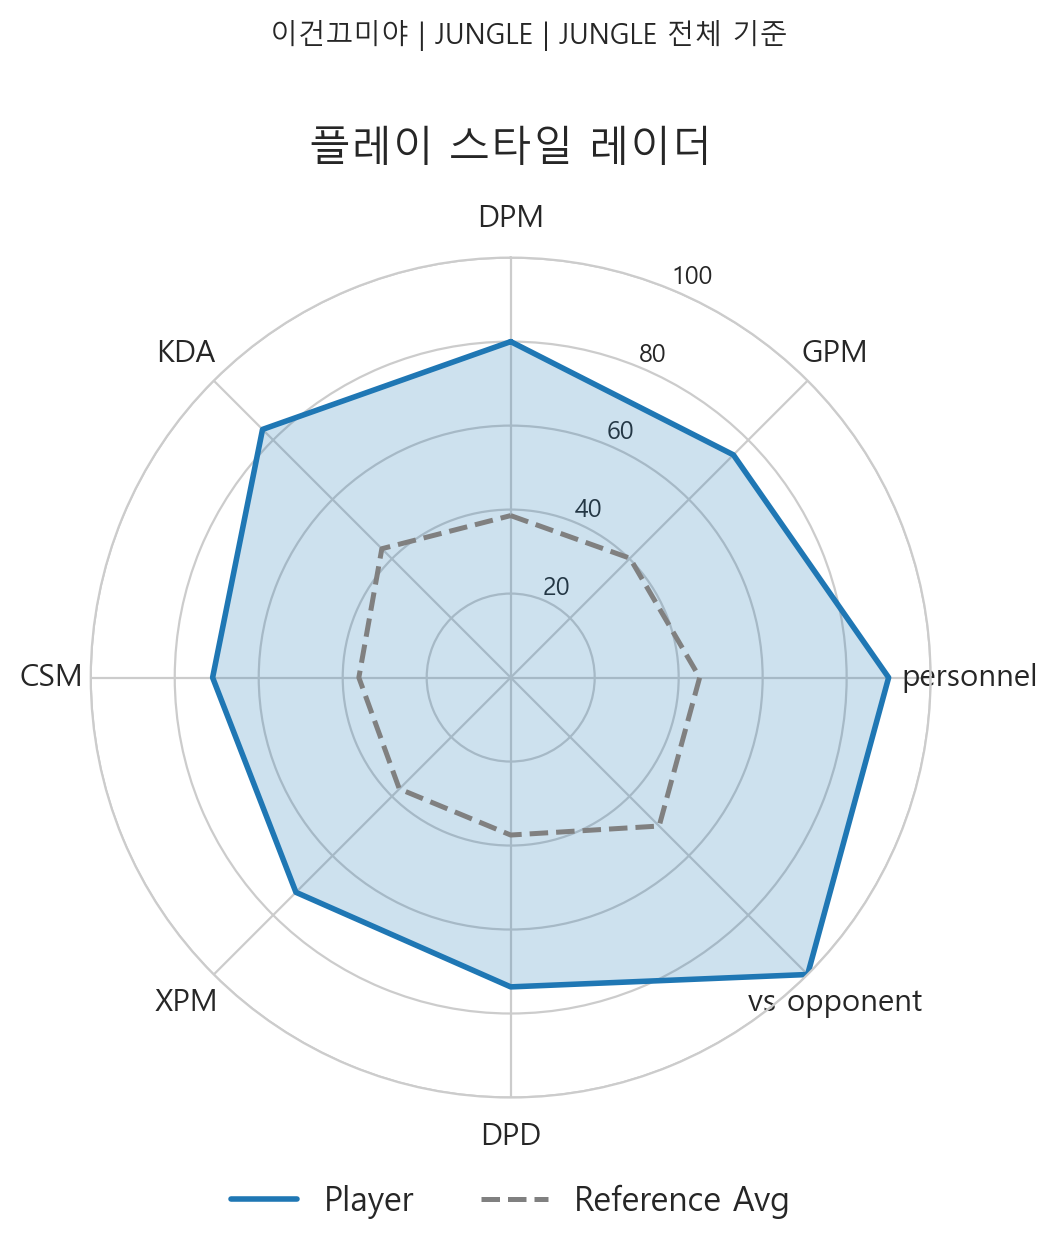


📖 지표 설명
- DPM: 분당 챔피언에게 가한 피해량. 교전 및 딜링 기여도를 보여준다.
- GPM: 분당 획득 골드. 아이템 성장 속도와 자원 확보 능력을 나타낸다.
- personnel: 게임 내 몇 인분 지표. 한 경기에서 개인이 차지한 기여도 비중을 의미한다.
- vs opponent: 동일 포지션 상대 대비 영향력 지표. 라인전 또는 맞상대 우위를 반영한다.
- DPD: 데스당 가한 피해량. 죽기 전까지 얼마나 효율적으로 딜을 넣었는지 보여준다.
- XPM: 분당 경험치. 레벨링 속도와 성장 안정성을 나타낸다.
- CSM: 분당 CS 수급량. 라인/정글 운영과 성장 속도를 나타낸다.
- KDA: 킬과 어시스트 대비 데스 비율. 교전 안정성과 생존 기여도를 함께 반영한다.

📌 리포트 요약
이건끄미야의 메인 포지션은 JUNGLE이며, 비교 기준은 JUNGLE 전체 기준입니다.
전체 승률은 59.7%입니다.
[기본 스타일] 생존형 딜러
→ 딜 지표와 데스 대비 효율이 모두 높아, 살아남으며 지속 딜을 확보하는 안정형 딜러 유형.
[포지션 보정 플레이 성향] 갱킹형 정글러
→ 교전 개입과 팀 기여가 높고, 맞정글 우위도 확보하는 주도형 갱킹 성향.

🎯 카테고리 요약


,유저명,메인 포지션,MMR 밴드,비교 기준,비교 유저 수,기본 스타일,스타일 설명,대표 성향,대표 성향 해석
0,이건끄미야,JUNGLE,1700~1800,JUNGLE 전체 기준,56,생존형 딜러,"딜 지표와 데스 대비 효율이 모두 높아, 살아남으며 지속 딜을 확보하는 안정형 딜러...",갱킹형 정글러,"교전 개입과 팀 기여가 높고, 맞정글 우위도 확보하는 주도형 갱킹 성향."



📊 핵심 지표 비교


,indicator,user,ref_avg,user_pct,ref_avg_pct
0,dpm,941.196262,686.117291,100.000000,48.214286
1,gold_per_min,510.728972,436.210250,100.000000,53.571429
2,game_n_person_contribution,1.124521,1.006164,100.000000,50.000000
3,game_impact_vs_opponent,56.540571,50.307938,100.000000,50.000000
4,damage_dealt_per_death,9446.168505,6204.496886,98.214286,50.000000
5,exp_per_min,542.839346,495.997093,96.428571,50.000000
6,cs_per_min,7.456075,6.557270,94.642857,48.214286
7,kda,6.982523,5.032953,92.857143,48.214286



🔥 포지션 기반 성향 분석


,포지션,지표 조합,플레이 성향,해석
0,JUNGLE,kda↑ + personnel↑ + vs opponent↑,갱킹형 정글러,"교전 개입과 팀 기여가 높고, 맞정글 우위도 확보하는 주도형 갱킹 성향."
1,JUNGLE,vs opponent↑ + personnel↑ + cs_per_min 중상,오브젝트/주도권형 정글러,상대 정글 대비 우위를 바탕으로 오브젝트와 전장 주도권을 만드는 성향.
2,JUNGLE,cs_per_min↑ + gold_per_min↑ + exp_per_min↑,파밍형 정글러,개입보다 성장 속도와 자원 확보를 통해 영향력을 만드는 파밍 중심 성향.



📡 레이더 지표


,indicator,user_pct,ref_avg_pct,weight,user_w_pct,ref_w_pct
0,dpm,100.000000,48.214286,0.80,80.000000,38.571429
1,gold_per_min,100.000000,53.571429,0.75,75.000000,40.178571
2,game_n_person_contribution,100.000000,50.000000,0.90,90.000000,45.000000
3,game_impact_vs_opponent,100.000000,50.000000,1.00,100.000000,50.000000
4,damage_dealt_per_death,98.214286,50.000000,0.75,73.660714,37.500000
5,exp_per_min,96.428571,50.000000,0.75,72.321429,37.500000
6,cs_per_min,94.642857,48.214286,0.75,70.982143,36.160714
7,kda,92.857143,48.214286,0.90,83.571429,43.392857


In [ ]:
run_player_report("이건끄미야")

In [44]:
# 1. 먼저 이것 확인
print('summary_df_elo' in globals())
print('mmr_df_updated_elo' in globals())
print('user_name' in globals())

True
True
True


In [45]:
print('position_dfs' in globals())
print(type(position_dfs))
print(position_dfs.keys())

False


NameError: name 'position_dfs' is not defined

In [46]:
print('position_dfs' in globals())
print(type(position_dfs))
print(position_dfs.keys())

False


NameError: name 'position_dfs' is not defined